# Trapped in a Low Dimension


Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.patches import Patch
from matplotlib.gridspec import GridSpec
import matplotlib.transforms as transforms
from matplotlib.patches import Ellipse
import seaborn as sns
from collections import defaultdict, Counter
import warnings
import h5py
warnings.filterwarnings('ignore')

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    silhouette_score, balanced_accuracy_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    cross_val_score, cross_val_predict,
    StratifiedKFold, GroupKFold, StratifiedGroupKFold,
)
from sklearn.pipeline import Pipeline

try:
    import umap
    UMAP_AVAILABLE = True
except ImportError:
    UMAP_AVAILABLE = False
    print('umap-learn not installed')

try:
    import cebra
    CEBRA_AVAILABLE = True
except ImportError:
    CEBRA_AVAILABLE = False
    print('cebra not installed')

%load_ext autoreload
%autoreload 2
import microns_datacleaner as mic
import microns_datacleaner.filters as fl


Global Config

In [ ]:
plt.rcParams.update({
    'figure.dpi': 120, 'font.size': 11, 'axes.titlesize': 13,
    'axes.labelsize': 12, 'axes.spines.top': False,
    'axes.spines.right': False, 'legend.frameon': False,
    'savefig.bbox': 'tight',
})

SEED    = 42
SESSION = '9_4'

BIN_SIZE        = 5
MIN_BINS        = 2

N_PCS_FOR_CLF  = 50
N_PCS_FOR_TSNE = 50
N_CV_SPLITS    = 5
N_SHUFFLES     = 50


Data Loading & Neuron Selection

In [ ]:
from pathlib import Path
import os

DATA_DIR = Path("data")
VERSION = 1718

if not DATA_DIR.exists():
    raise FileNotFoundError(
        "data not found"
    )

cleaner = mic.MicronsDataCleaner.__new__(mic.MicronsDataCleaner)
cleaner.version = VERSION
cleaner.datadir = str(DATA_DIR)
cleaner.homedir = Path().resolve()
cleaner.data_storage = str(cleaner.homedir / cleaner.datadir / str(cleaner.version))

cleaner._configure_download_tables(VERSION, download_policy="minimum", extra_tables=[])

required_tables = [
    cleaner.tables["nucleus"],
    cleaner.tables["celltype"],
    cleaner.tables["proofreading"],
    cleaner.tables["brain_areas"],
]

if "func_props" in cleaner.tables and cleaner.tables["func_props"] is not None:
    required_tables.append(cleaner.tables["func_props"])

required_tables += list(cleaner.info_to_correct.keys())
required_files = [f"{t}.csv" for t in required_tables if t is not None]

candidate_raw_dirs = [
    DATA_DIR / str(VERSION) / "raw",
    DATA_DIR / "raw",
]

raw_dir = None

for d in candidate_raw_dirs:
    if d.exists():
        existing = {x.name for x in d.glob("*.csv")}
        if all(fname in existing for fname in required_files):
            raw_dir = d
            break

if raw_dir is None:
    debug = []
    for d in candidate_raw_dirs:
        if d.exists():
            debug.append(f"{d}: {[x.name for x in d.glob('*.csv')][:20]}")
        else:
            debug.append(f"{d}: MISSING")

    raise FileNotFoundError(
        "Could not find these files:"
        f"{required_files}\n\n"
        "Checked:\n" + "\n".join(debug)
    )

cleaner.data_storage = str(raw_dir.parent)

units, segments = cleaner.process_nucleus_data(functional_data="best_only")

print(f"Total units loaded: {len(units)}")

v1_neurons = fl.filter_neurons(
    units,
    brain_area="V1",
    proofread="ax_clean",
    tuning="matched"
)

v1_exc = v1_neurons[v1_neurons["classification_system"] == "excitatory_neuron"]
v1_inh = v1_neurons[v1_neurons["classification_system"] == "inhibitory_neuron"]

print(f"\nV1 neurons proofread + matched tuning: {len(v1_neurons)}")
print(f"Excitatory: {len(v1_exc)}")
print(f"Inhibitory: {len(v1_inh)}")


Transform positions:   0%|          | 0/94014 [00:00<?, ?it/s]


Transform positions:   7%|▋         | 6131/94014 [00:00<00:01, 61301.58it/s]


Transform positions:  13%|█▎        | 12262/94014 [00:00<00:01, 61257.94it/s]


Transform positions:  20%|█▉        | 18390/94014 [00:00<00:01, 61266.70it/s]


Transform positions:  26%|██▌       | 24554/94014 [00:00<00:01, 61411.75it/s]

...


Transform positions:  85%|████████▌ | 79942/94014 [00:01<00:00, 61542.07it/s]


Transform positions:  92%|█████████▏| 86097/94014 [00:01<00:00, 61510.13it/s]


Transform positions:  98%|█████████▊| 92265/94014 [00:01<00:00, 61560.25it/s]


Transform positions: 100%|██████████| 94014/94014 [00:01<00:00, 61417.43it/s]

Total units loaded: 90434

V1 neurons proofread + matched tuning: 728
Excitatory: 728
Inhibitory: 0


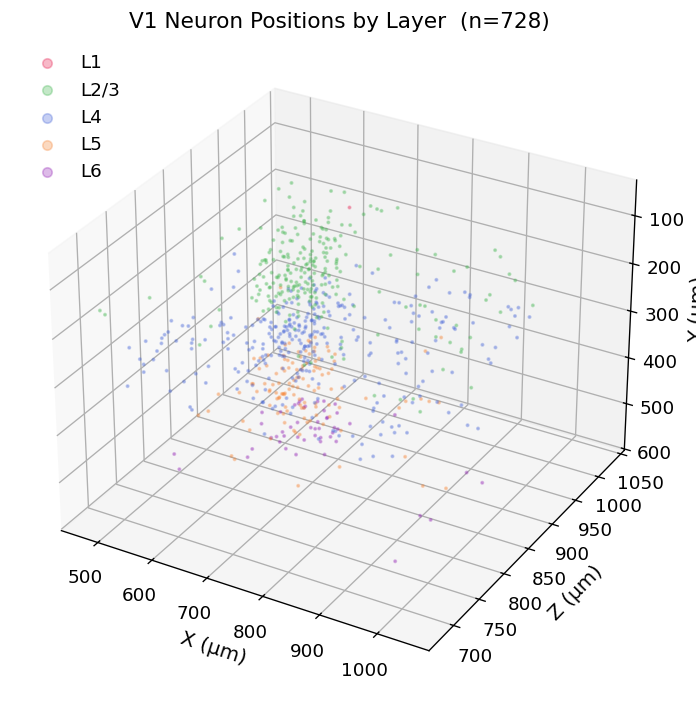

In [4]:
fig = plt.figure(figsize=(8, 6))
ax  = fig.add_subplot(projection='3d')
ax.zaxis.set_inverted(True)

LAYER_COLORS = {
    'L1': '#e6194b', 'L2/3': '#3cb44b',
    'L4': '#4363d8', 'L5': '#f58231', 'L6': '#911eb4'
}

for layer, color in LAYER_COLORS.items():
    ul = fl.filter_neurons(v1_neurons, layer=layer)
    if len(ul):
        ax.scatter(ul['pt_position_x'], ul['pt_position_z'], ul['pt_position_y'],
                   alpha=0.3, s=2, color=color, label=layer)

ax.set_xlabel('X (µm)'); ax.set_ylabel('Z (µm)'); ax.set_zlabel('Y (µm)')
ax.set_title(f'V1 Neuron Positions by Layer  (n={len(v1_neurons)})')
ax.legend(markerscale=4, loc='upper left')
plt.tight_layout()
plt.show()

Session-level Neuron Filter

In [5]:
with h5py.File('microns.h5', 'r') as f:
    session_unit_ids = f['sessions'][SESSION]['meta']['unit_ids'][:]

print(f"Columns in r['responses']: {len(session_unit_ids)}")

v1_with_uid = v1_neurons.dropna(subset=['unit_id']).copy()
v1_with_uid['unit_id_int'] = v1_with_uid['unit_id'].astype(int)
trusted_unit_ids = set(v1_with_uid['unit_id_int'].values)

print(f"\nTrusted filtered neuron IDs: {len(trusted_unit_ids)}")

keep_neuron_cols = np.where(np.isin(session_unit_ids, list(trusted_unit_ids)))[0]
print(f"Overlap: {len(keep_neuron_cols)}")
print(f"Columns dropped: {len(session_unit_ids) - len(keep_neuron_cols)}")

uid_to_meta = v1_with_uid.drop_duplicates(subset=['unit_id_int']).set_index('unit_id_int')

def get_meta_val(uid, col):
    if uid in uid_to_meta.index:
        val = uid_to_meta.at[uid, col]
        return str(val) if not isinstance(val, str) else val
    return 'unknown'

trusted_meta = pd.DataFrame([
    {
        'unit_id': int(uid),
        'layer': get_meta_val(uid, 'layer'),
        'classification_system': get_meta_val(uid, 'classification_system'),
    }
    for uid in session_unit_ids[keep_neuron_cols]
])

n_known = (trusted_meta['layer'] != 'unknown').sum()
print(f"\nMetadata known for {n_known} / {len(trusted_meta)} neurons")
print(f"Layer distribution:\n{trusted_meta['layer'].value_counts().to_string()}")


Columns in r['responses']: 7855

Trusted filtered neuron IDs: 698
Overlap: 579
Columns dropped: 7276

Metadata known for 579 / 579 neurons
Layer distribution:
layer
L4      257
L2/3    220
L5       89
L6       12
L1        1


## Part I — Trial-Averaged Decoding

### Population Response Matrix

In [6]:
funcreader = mic.MicronsFunctionalReader(path='microns.h5')
hashes = funcreader.get_hashes_by_session(SESSION)

stim_types = [funcreader.get_video_type(h) for h in hashes]
type_counts = Counter(stim_types)

print(f"Total trials: {len(hashes)}")
print("\nStimulus types:")
for k, v in sorted(type_counts.items(), key=lambda x: -x[1]):
    print(f"{k:22s}: {v:4d} trials")

Total trials: 464

Stimulus types:
Clip                  :  384 trials
Monet2                :   40 trials
Trippy                :   40 trials


In [7]:
hash_to_responses = defaultdict(list)
hash_to_type      = {}
n_failed = 0

print("Loading trial responses")
for trial_idx, h in enumerate(hashes):
    hash_to_type[h] = funcreader.get_video_type(h)
    try:
        r = funcreader.get_trial(SESSION, trial_idx)
        if r is None or 'responses' not in r:
            n_failed += 1
            continue
        mean_resp = r['responses'][keep_neuron_cols, :].mean(axis=1)
        hash_to_responses[h].append(mean_resp)
    except Exception:
        n_failed += 1

print(f"{len(hash_to_responses)} unique stimuli") 
print(f"{n_failed} trials skipped")

unique_hashes = sorted(hash_to_responses.keys())
R_matrix  = np.array([np.mean(hash_to_responses[h], axis=0) for h in unique_hashes])
labels_raw = np.array([hash_to_type[h] for h in unique_hashes])

print(f"\nResponse matrix shape: {R_matrix.shape}")
	# rows = unique stimuli
	# cols = trusted neurons
print("\nStimulus distribution:")
for lbl, cnt in Counter(labels_raw).items():
    print(f"{lbl:22s}: {cnt}")

Loading trial responses


280 unique stimuli
0 trials skipped

Response matrix shape: (280, 579)

Stimulus distribution:
Trippy                : 20
Clip                  : 240
Monet2                : 20


### Preprocessing

In [8]:
nan_frac     = np.isnan(R_matrix).mean(axis=0)
keep_neurons = nan_frac < 0.10
R_clean      = R_matrix[:, keep_neurons].copy()
print(f"Neurons after nan filter: {keep_neurons.sum()} / {R_matrix.shape[1]}")

trusted_meta_clean = trusted_meta[keep_neurons].reset_index(drop=True)

col_means = np.nanmean(R_clean, axis=0)
nan_idx   = np.where(np.isnan(R_clean))
R_clean[nan_idx] = np.take(col_means, nan_idx[1])

active  = R_clean.std(axis=1) > 1e-6
R_clean = R_clean[active]
labels  = labels_raw[active]
print(f"Stimuli after activity filter: {active.sum()} / {R_matrix.shape[0]}")

scaler   = StandardScaler()
R_scaled = scaler.fit_transform(R_clean)

print(f"\nFinal matrix: {R_scaled.shape}")
print(f"Mean: {R_scaled.mean():+.4f}  Std: {R_scaled.std():+.4f}")

Neurons after nan filter: 579 / 579
Stimuli after activity filter: 280 / 280

Final matrix: (280, 579)
Mean: -0.0000  Std: +1.0000


Stimulus distribution:
Clip                    n= 240  (85.7%)
Monet2                  n=  20  (7.1%)
Trippy                  n=  20  (7.1%)

Majority-class baseline: 0.857


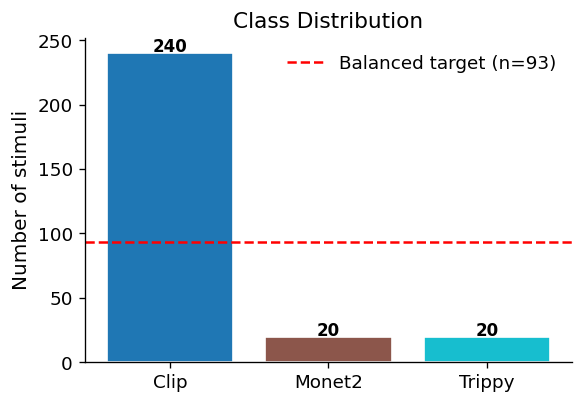

In [9]:
unique_labels  = sorted(set(labels))
n_types        = len(unique_labels)
palette        = plt.cm.get_cmap('tab10', n_types)
label_to_color = {lbl: palette(i) for i, lbl in enumerate(unique_labels)}
le             = LabelEncoder()
y              = le.fit_transform(labels)
counts         = {lbl: int(np.sum(labels == lbl)) for lbl in unique_labels}
majority_frac  = max(counts.values()) / len(labels)
chance_level   = 1.0 / n_types
legend_patches = [Patch(color=label_to_color[l], label=l) for l in unique_labels]

print("Stimulus distribution:")
for lbl, n in counts.items():
    print(f"{lbl:22s}  n={n:4d}  ({100*n/len(labels):.1f}%)")
print(f"\nMajority-class baseline: {majority_frac:.3f}")

cv_bal  = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
clf_bal = LogisticRegression(max_iter=2000, C=1.0, random_state=SEED, class_weight='balanced')

fig, ax = plt.subplots(figsize=(5, 3.5))
bars = ax.bar(list(counts.keys()), list(counts.values()),
              color=[label_to_color[l] for l in counts], edgecolor='white')
ax.axhline(len(labels) / n_types, color='red', ls='--',
           label=f'Balanced target (n={len(labels)//n_types})')
for bar, v in zip(bars, counts.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(v), ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel('Number of stimuli')
ax.set_title('Class Distribution')
ax.legend(); plt.tight_layout()
plt.show()


#### PCA

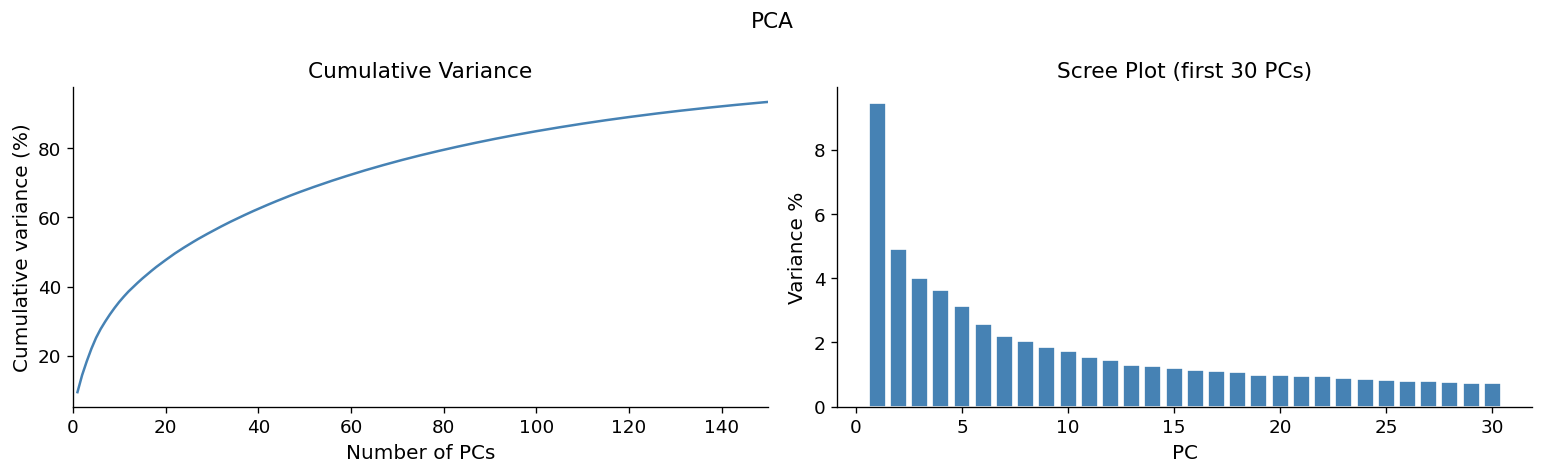

PCs for 80% variance: 82
PCs for 90% variance: 126
Variance in PC1: 9.47%
Variance in PC1+PC2: 14.39%
Variance in PC1-PC10: 35.56%
Participation ratio (eff dim): 47.2


In [10]:
n_pcs = min(150, R_scaled.shape[0] - 1, R_scaled.shape[1] - 1)
pca = PCA(n_components=n_pcs, random_state=SEED)
R_pca = pca.fit_transform(R_scaled)
cumvar = np.cumsum(pca.explained_variance_ratio_)
ev = pca.explained_variance_ratio_
participation_ratio = 1.0 / np.sum(ev ** 2)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(np.arange(1, n_pcs + 1), cumvar * 100, '-', lw=1.5, color='steelblue')
axes[0].set_xlabel('Number of PCs'); axes[0].set_ylabel('Cumulative variance (%)')
axes[0].set_title('Cumulative Variance'); axes[0].legend(); axes[0].set_xlim(0, n_pcs)

axes[1].bar(np.arange(1, 31), ev[:30] * 100, color='steelblue', edgecolor='white')
axes[1].set_xlabel('PC'); axes[1].set_ylabel('Variance %')
axes[1].set_title('Scree Plot (first 30 PCs)')

plt.suptitle('PCA', fontsize=13)
plt.tight_layout()
plt.show()

n80 = min(int(np.searchsorted(cumvar, 0.80)) + 1, n_pcs)
n90 = min(int(np.searchsorted(cumvar, 0.90)) + 1, n_pcs)
print(f"PCs for 80% variance: {n80}")
print(f"PCs for 90% variance: {n90}")
print(f"Variance in PC1: {ev[0]*100:.2f}%")
print(f"Variance in PC1+PC2: {cumvar[1]*100:.2f}%")
print(f"Variance in PC1-PC10: {cumvar[9]*100:.2f}%")
print(f"Participation ratio (eff dim): {participation_ratio:.1f}")

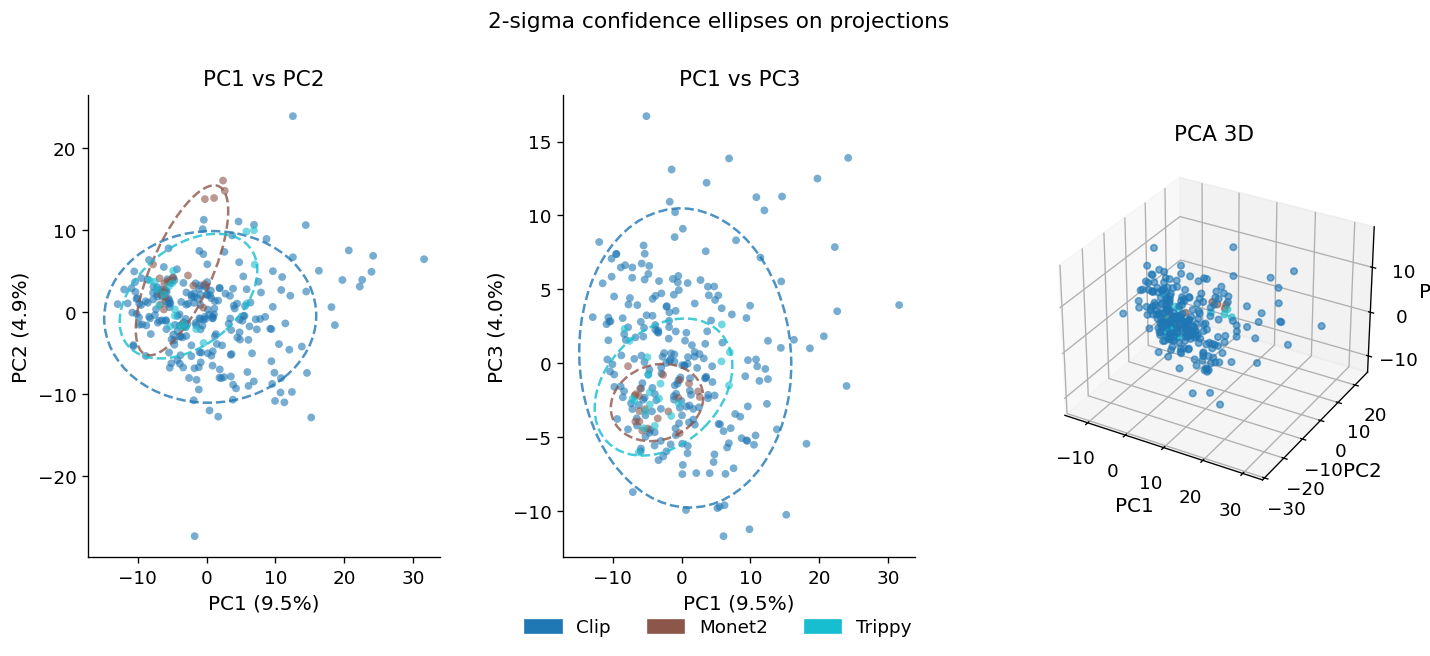

In [11]:
def confidence_ellipse(x, y, ax, n_std=2.0, **kwargs):
    if len(x) < 3: return
    cov = np.cov(x, y)
    pearson = cov[0,1] / np.sqrt(cov[0,0] * cov[1,1])
    rx, ry = np.sqrt(1 + pearson), np.sqrt(1 - pearson)
    scale_x = np.sqrt(cov[0,0]) * n_std
    scale_y = np.sqrt(cov[1,1]) * n_std
    ellipse = Ellipse((0,0), width=rx*2, height=ry*2, **kwargs)
    t = (transforms.Affine2D().rotate_deg(45)
         .scale(scale_x, scale_y).translate(x.mean(), y.mean()))
    ellipse.set_transform(t + ax.transData)
    return ax.add_patch(ellipse)

fig = plt.figure(figsize=(14, 5))
gs  = GridSpec(1, 3, figure=fig, wspace=0.35)

for col, (xi, yi, title) in enumerate([
        (0, 1, f'PC1 vs PC2'),
        (0, 2, f'PC1 vs PC3'),
        (None, None, 'PCA 3D')]):
    if col < 2:
        ax = fig.add_subplot(gs[col])
        for lbl in unique_labels:
            m = labels == lbl
            ax.scatter(R_pca[m,xi], R_pca[m,yi], color=label_to_color[lbl],
                       alpha=0.6, s=22, edgecolors='none', label=lbl)
            confidence_ellipse(R_pca[m,xi], R_pca[m,yi], ax, n_std=2,
                               edgecolor=label_to_color[lbl], facecolor='none',
                               lw=1.5, ls='--', alpha=0.8)
        ax.set_xlabel(f'PC{xi+1} ({ev[xi]*100:.1f}%)')
        ax.set_ylabel(f'PC{yi+1} ({ev[yi]*100:.1f}%)')
        ax.set_title(title)
    else:
        ax = fig.add_subplot(gs[2], projection='3d')
        for lbl in unique_labels:
            m = labels == lbl
            ax.scatter(R_pca[m,0], R_pca[m,1], R_pca[m,2],
                       color=label_to_color[lbl], alpha=0.6, s=15)
        ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.set_zlabel('PC3')
        ax.set_title('PCA 3D')

fig.legend(handles=legend_patches, loc='lower center', ncol=n_types,
           bbox_to_anchor=(0.5, -0.05))
plt.suptitle('2-sigma confidence ellipses on projections', fontsize=13, y=1.02)
plt.show()

#### t-SNE

running


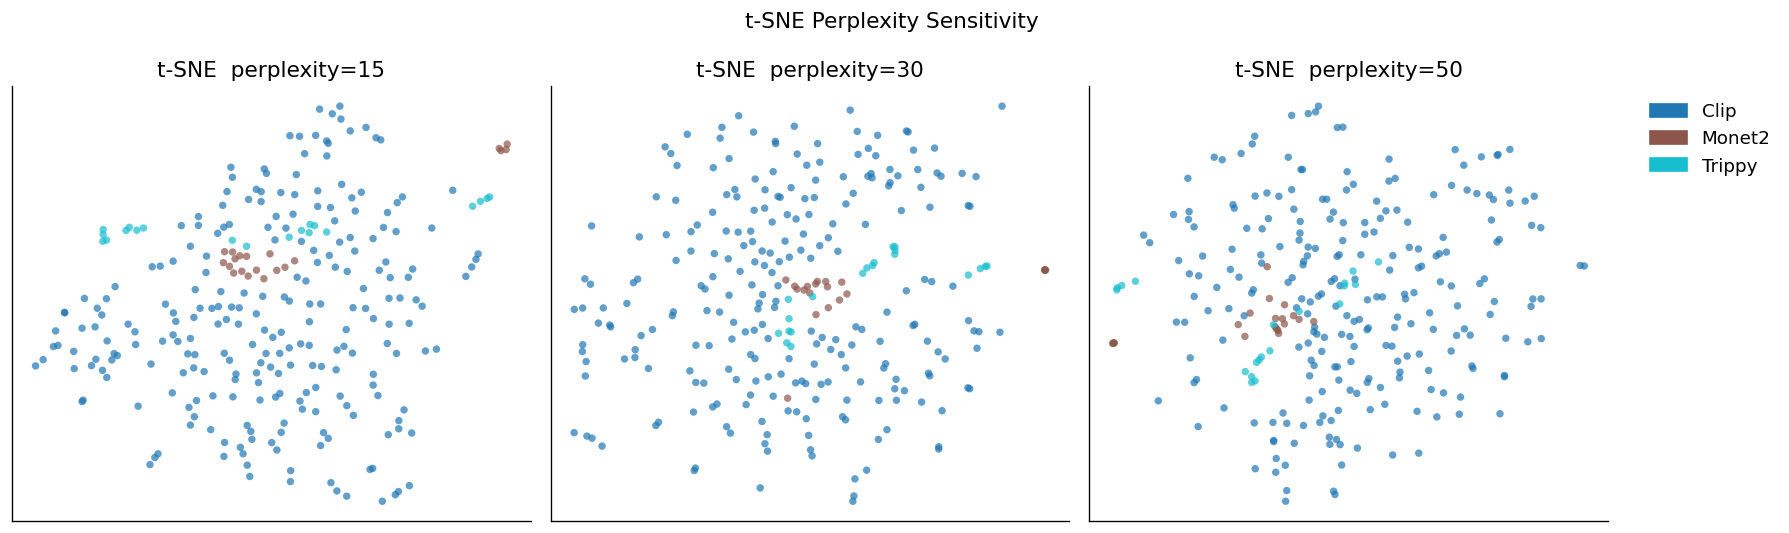

In [12]:
n_pca_for_tsne = min(50, n_pcs)
tsne_results = {}
PERPLEXITIES = [15, 30, 50]

print("running")
for perp in PERPLEXITIES:
    tsne = TSNE(n_components=2, perplexity=perp, random_state=SEED,
                max_iter=1000, learning_rate='auto', init='pca')
    tsne_results[perp] = tsne.fit_transform(R_pca[:, :n_pca_for_tsne])

R_tsne = tsne_results[30]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, perp in zip(axes, PERPLEXITIES):
    for lbl in unique_labels:
        m = labels == lbl
        ax.scatter(tsne_results[perp][m,0], tsne_results[perp][m,1],
                   color=label_to_color[lbl], alpha=0.7, s=20, edgecolors='none')
    ax.set_title(f't-SNE  perplexity={perp}')
    ax.set_xticks([]); ax.set_yticks([])
axes[-1].legend(handles=legend_patches, bbox_to_anchor=(1.05,1), loc='upper left')
plt.suptitle('t-SNE Perplexity Sensitivity', fontsize=13)
plt.tight_layout()
plt.show()

#### UMAP

running


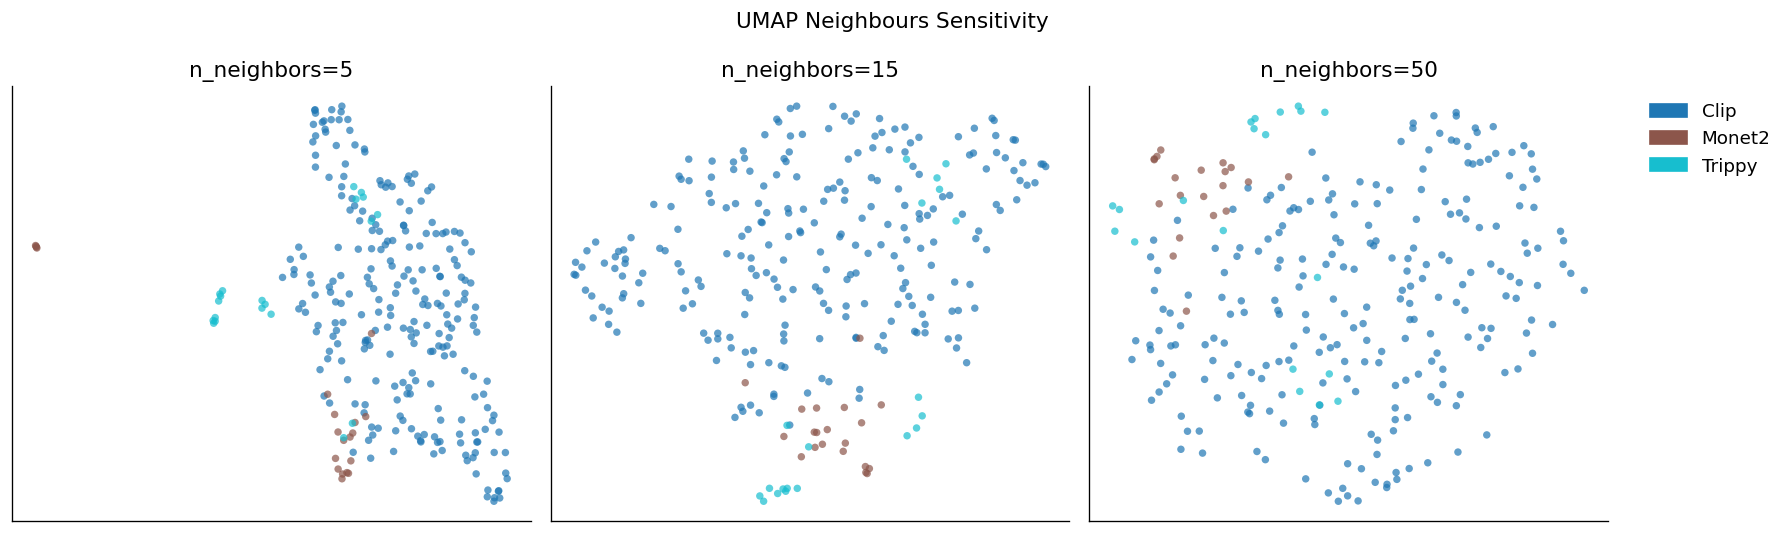

In [13]:
R_umap = None
if UMAP_AVAILABLE:
    umap_results = {}
    N_NEIGHBORS_LIST = [5, 15, 50]
    print("running")
    for nn in N_NEIGHBORS_LIST:
        reducer = umap.UMAP(n_components=2, n_neighbors=nn, min_dist=0.1,
                            metric='euclidean', random_state=SEED)
        umap_results[nn] = reducer.fit_transform(R_pca[:, :n_pca_for_tsne])
    R_umap = umap_results[15]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    for ax, nn in zip(axes, N_NEIGHBORS_LIST):
        for lbl in unique_labels:
            m = labels == lbl
            ax.scatter(umap_results[nn][m,0], umap_results[nn][m,1],
                       color=label_to_color[lbl], alpha=0.7, s=20, edgecolors='none')
        ax.set_title(f'n_neighbors={nn}')
        ax.set_xticks([]); ax.set_yticks([])
    axes[-1].legend(handles=legend_patches, bbox_to_anchor=(1.05,1), loc='upper left')
    plt.suptitle('UMAP Neighbours Sensitivity', fontsize=13)
    plt.tight_layout()
    plt.show()

#### CEBRA


  0%|          | 0/2000 [00:00<?, ?it/s]


pos: -0.5058 neg:  5.3288 total:  4.8230 temperature:  1.0000:   0%|          | 0/2000 [00:00<?, ?it/s]


pos: -0.5058 neg:  5.3288 total:  4.8230 temperature:  1.0000:   0%|          | 1/2000 [00:00<05:29,  6.07it/s]


pos: -0.5845 neg:  5.3758 total:  4.7913 temperature:  1.0000:   0%|          | 1/2000 [00:00<05:29,  6.07it/s]


pos: -0.6218 neg:  5.3744 total:  4.7526 temperature:  1.0000:   0%|          | 1/2000 [00:00<05:29,  6.07it/s]

...


pos: -0.5538 neg:  5.2766 total:  4.7228 temperature:  1.0000: 100%|█████████▉| 1991/2000 [00:26<00:00, 75.52it/s]


pos: -0.5548 neg:  5.2754 total:  4.7206 temperature:  1.0000: 100%|█████████▉| 1991/2000 [00:26<00:00, 75.52it/s]


pos: -0.5548 neg:  5.2754 total:  4.7206 temperature:  1.0000: 100%|█████████▉| 1999/2000 [00:26<00:00, 75.66it/s]


pos: -0.5713 neg:  5.3023 total:  4.7310 temperature:  1.0000: 100%|█████████▉| 1999/2000 [00:26<00:00, 75.66it/s]


pos: -0.5713 neg:  5.3023 total:  4.7310 temperature:  1.0000: 100%|██████████| 2000/2000 [00:26<00:00, 75.64it/s]

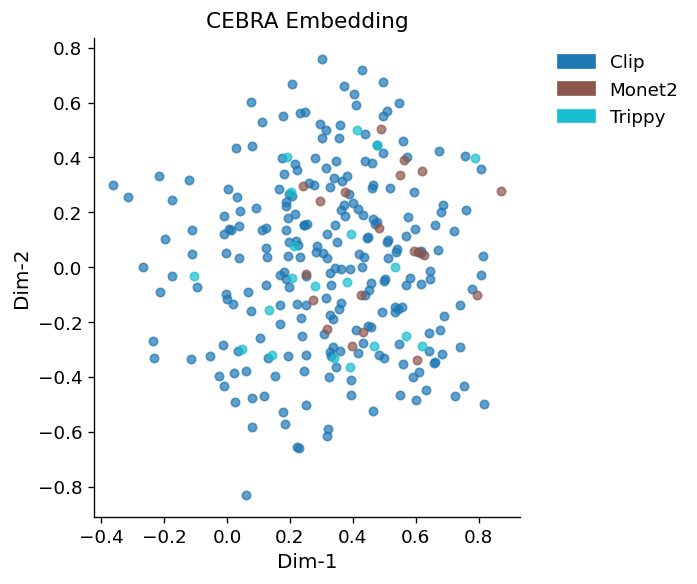

In [14]:
R_cebra = None

if CEBRA_AVAILABLE:
    try:
        import torch
        label_cont = y.astype(np.float32).reshape(-1, 1)
        cb_model = cebra.CEBRA(
            model_architecture='offset10-model',
            batch_size=min(512, len(R_scaled)//2),
            learning_rate=3e-4,
            temperature=1.0,
            output_dimension=8,
            max_iterations=2000,
            device='cpu',
            verbose=True,
        )
        cb_model.fit(R_scaled.astype(np.float32), label_cont)
        R_cebra = cb_model.transform(R_scaled.astype(np.float32))

        fig, ax = plt.subplots(figsize=(6,5))
        for lbl in unique_labels:
            m = labels == lbl
            ax.scatter(R_cebra[m,0], R_cebra[m,1], color=label_to_color[lbl],
                       alpha=0.7, s=25, label=lbl)
        ax.set_title('CEBRA Embedding')
        ax.set_xlabel('Dim-1'); ax.set_ylabel('Dim-2')
        ax.legend(handles=legend_patches, bbox_to_anchor=(1.05,1), loc='upper left')
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"CEBRA failed: {e}")
        R_cebra = None
else:
    print("CEBRA not installed")

#### DR Comparison

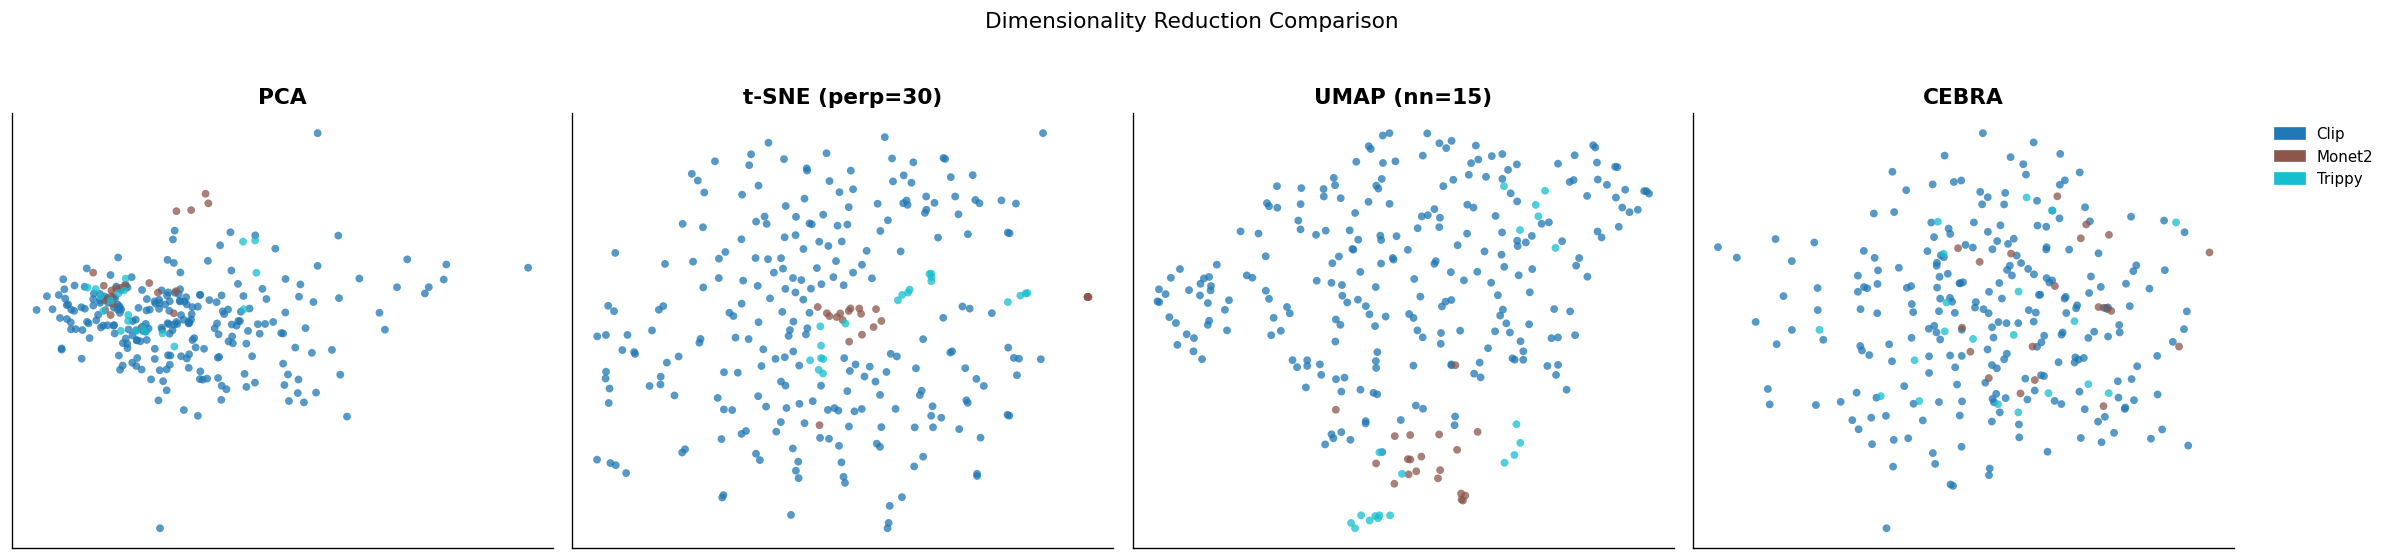

In [15]:
methods = [('PCA', R_pca[:, :2]), ('t-SNE (perp=30)', R_tsne)]
if UMAP_AVAILABLE  and R_umap  is not None: methods.append(('UMAP (nn=15)',  R_umap))
if CEBRA_AVAILABLE and R_cebra is not None: methods.append(('CEBRA', R_cebra[:, :2]))

fig, axes = plt.subplots(1, len(methods), figsize=(5 * len(methods), 4.5))
if len(methods) == 1: axes = [axes]

for ax, (name, emb) in zip(axes, methods):
    for lbl in unique_labels:
        m = labels == lbl
        ax.scatter(emb[m,0], emb[m,1], color=label_to_color[lbl],
                   alpha=0.75, s=22, edgecolors='none')
    ax.set_title(name, fontsize=13, fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])

axes[-1].legend(handles=legend_patches, bbox_to_anchor=(1.05,1), loc='upper left', fontsize=9)
plt.suptitle('Dimensionality Reduction Comparison',
             fontsize=13, y=1.03)
plt.tight_layout()
plt.show()

### Quantitative Evaluation

In [16]:
sil_scores = {}
for name, emb in methods:
    sil_scores[name] = silhouette_score(emb, y)
for k in [2, 5, 10, 20, 50]:
    if k < R_pca.shape[1]:
        sil_scores[f'PCA-{k}D'] = silhouette_score(R_pca[:, :k], y)

print("Silhouette — FULL dataset")
for name, sc in sorted(sil_scores.items(), key=lambda x: -x[1]):
    print(f"{name:25s}  {sc:+.4f}")


Silhouette — FULL dataset
UMAP (nn=15)               +0.1247
t-SNE (perp=30)            -0.1088
PCA-10D                    -0.1137
PCA-20D                    -0.1192
CEBRA                      -0.1228
PCA                        -0.1269
PCA-2D                     -0.1269
PCA-5D                     -0.1285
PCA-50D                    -0.1313


In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin

class FoldUMAP(BaseEstimator, TransformerMixin):
    """sklearn-compatible UMAP that re-fits on every training fold."""
    def __init__(self, n_components=2, n_neighbors=15, min_dist=0.1, random_state=SEED):
        self.n_components = n_components
        self.n_neighbors  = n_neighbors
        self.min_dist     = min_dist
        self.random_state = random_state
    def fit(self, X, y=None):
        import umap
        nn = max(2, min(self.n_neighbors, len(X) - 1))
        self.model_ = umap.UMAP(n_components=self.n_components, n_neighbors=nn,
                                 min_dist=self.min_dist,
                                 random_state=self.random_state).fit(X)
        return self
    def transform(self, X):
        return self.model_.transform(X)

class FoldCEBRA(BaseEstimator, TransformerMixin):
    """sklearn-compatible CEBRA that re-fits on every training fold."""
    def __init__(self, output_dimension=2, max_iterations=300, batch_size=64, random_state=SEED):
        self.output_dimension = output_dimension
        self.max_iterations   = max_iterations
        self.batch_size       = batch_size
        self.random_state     = random_state
    def fit(self, X, y=None):
        import cebra
        label_cont = (np.asarray(y).astype(float).reshape(-1, 1)
                      if y is not None else None)
        self.model_ = cebra.CEBRA(
            model_architecture='offset1-model',
            output_dimension=self.output_dimension,
            max_iterations=self.max_iterations,
            batch_size=min(self.batch_size, max(2, len(X) // 2)),
            verbose=False,
        )
        self.model_.fit(X.astype(np.float32), label_cont)
        return self
    def transform(self, X):
        return self.model_.transform(X.astype(np.float32))

def make_emb_pipeline(kind, n_samples, n_features, n_pca_components=None):
    n_pca_components = n_pca_components or min(50, max(2, n_samples - 2), n_features)
    steps = [('scale', StandardScaler())]
    if kind == 'PCA':
        steps.append(('pca', PCA(n_components=min(2, n_features), random_state=SEED)))
    elif kind == 'UMAP':
        steps += [('pca',  PCA(n_components=n_pca_components, random_state=SEED)),
                  ('umap', FoldUMAP(n_components=2, n_neighbors=15))]
    elif kind == 'CEBRA':
        steps.append(('cebra', FoldCEBRA(output_dimension=2)))
    else:
        raise ValueError(f"Unknown embedding kind: {kind}")
    steps.append(('clf', LogisticRegression(max_iter=2000, C=1.0,
                                            class_weight='balanced',
                                            random_state=SEED)))
    return Pipeline(steps)


cv_kinds = [('PCA', 'PCA'), ('UMAP (nn=15)', 'UMAP')]
if CEBRA_AVAILABLE:
    cv_kinds.append(('CEBRA', 'CEBRA'))

clf_scores     = {}
clf_scores_bal = {}
clf_scores_f1  = {}

X_raw_cv = R_clean
for name, kind in cv_kinds:
    pipe = make_emb_pipeline(kind, X_raw_cv.shape[0], X_raw_cv.shape[1])
    clf_scores[name]     = cross_val_score(pipe, X_raw_cv, y, cv=cv_bal,
                                       scoring='accuracy').mean()
    clf_scores_bal[name] = cross_val_score(pipe, X_raw_cv, y, cv=cv_bal,
                                       scoring='balanced_accuracy').mean()
    clf_scores_f1[name]  = cross_val_score(pipe, X_raw_cv, y, cv=cv_bal,
                                       scoring='f1_macro').mean()

from sklearn.metrics import classification_report
print('Accuracy per class (leakage-free CV)')
for name, kind in cv_kinds:
    pipe = make_emb_pipeline(kind, X_raw_cv.shape[0], X_raw_cv.shape[1])
    y_pred = cross_val_predict(pipe, X_raw_cv, y, cv=cv_bal)
    print(f'\n{name}')
    print(classification_report(y, y_pred, target_names=le.classes_))

print(f'\nBalanced accuracy (chance={chance_level:.3f}, majority baseline={majority_frac:.3f})')
for name, bacc in sorted(clf_scores_bal.items(), key=lambda x: -x[1]):
    f1 = clf_scores_f1.get(name, float('nan'))
    print(f'{name:25s}  bal_acc={bacc:.4f}  F1_macro={f1:.4f}')

Accuracy per class (leakage-free CV)



PCA
              precision    recall  f1-score   support

        Clip       0.95      0.60      0.73       240
      Monet2       0.21      0.70      0.33        20
      Trippy       0.10      0.30      0.15        20

    accuracy                           0.59       280
   macro avg       0.42      0.53      0.40       280
weighted avg       0.83      0.59      0.66       280




UMAP (nn=15)
              precision    recall  f1-score   support

        Clip       0.99      0.53      0.69       240
      Monet2       0.20      0.90      0.32        20
      Trippy       0.10      0.30      0.15        20

    accuracy                           0.54       280
   macro avg       0.43      0.58      0.39       280
weighted avg       0.87      0.54      0.62       280




CEBRA
              precision    recall  f1-score   support

        Clip       1.00      0.93      0.96       240
      Monet2       0.66      0.95      0.78        20
      Trippy       0.50      0.70      0.58        20

    accuracy                           0.91       280
   macro avg       0.72      0.86      0.77       280
weighted avg       0.94      0.91      0.92       280


Balanced accuracy (chance=0.333, majority baseline=0.857)
CEBRA                      bal_acc=0.7653  F1_macro=0.7386
UMAP (nn=15)               bal_acc=0.5750  F1_macro=0.3891
PCA                        bal_acc=0.5333  F1_macro=0.4019


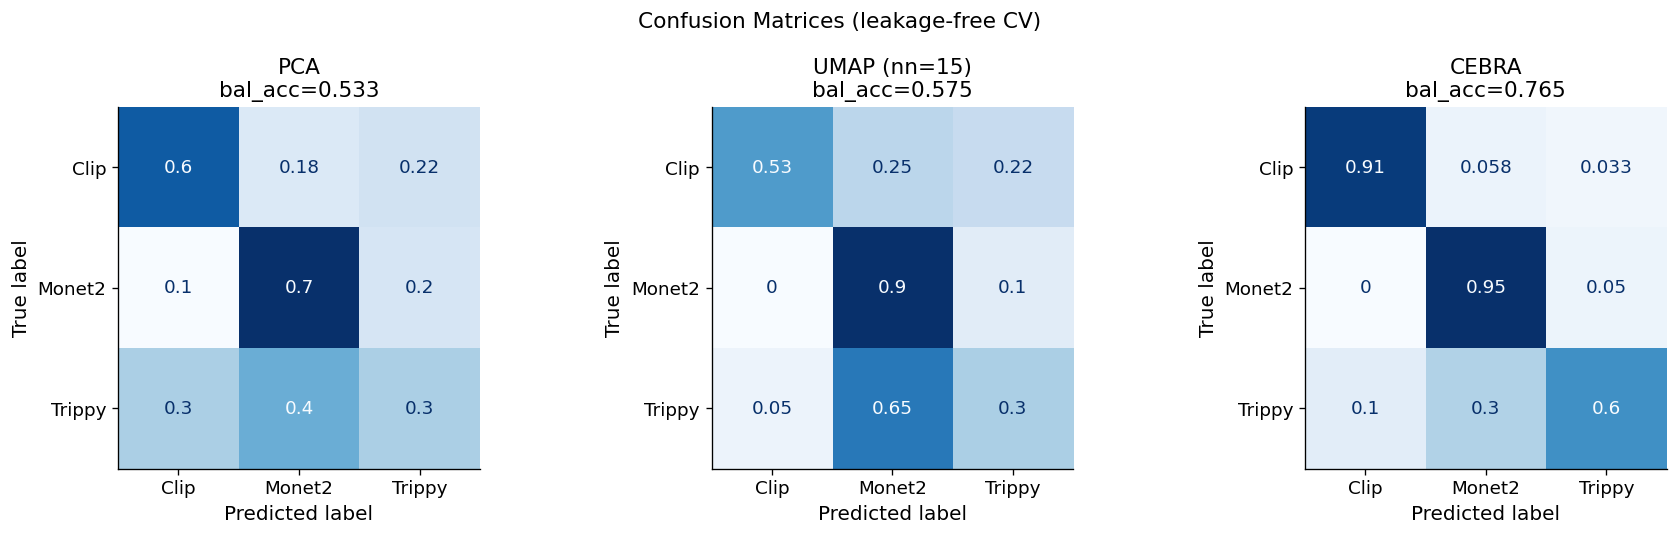

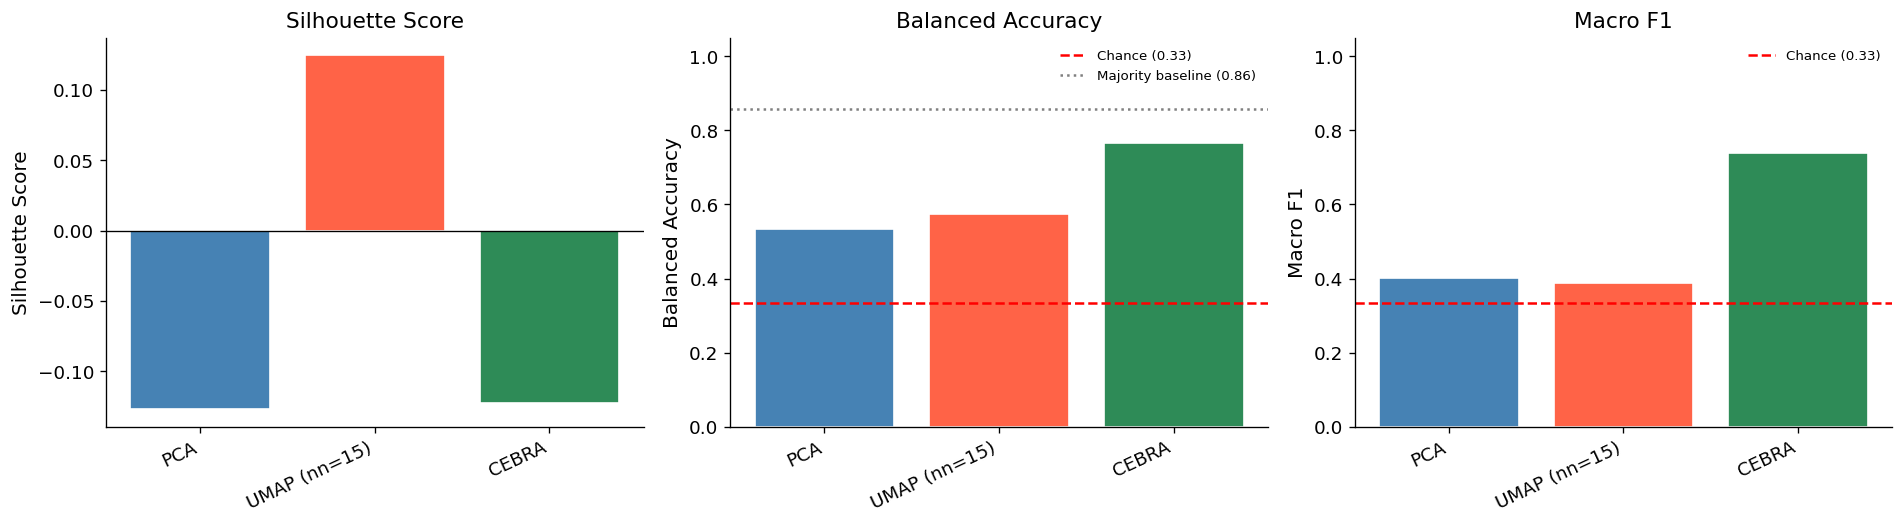

In [ ]:
plot_methods = [(n, e) for (n, e) in methods if not n.startswith('t-SNE')]

fig, axes = plt.subplots(1, len(plot_methods), figsize=(5*len(plot_methods), 4.5))
if len(plot_methods) == 1: axes = [axes]

_kind_lookup = {'PCA': 'PCA', 'UMAP (nn=15)': 'UMAP', 'CEBRA': 'CEBRA'}

for ax, (name, emb) in zip(axes, plot_methods):
    kind = _kind_lookup.get(name)
    if kind is None:
        ax.text(0.5, 0.5, f'{name}\n(no out-of-sample\ntransform)',
                ha='center', va='center', transform=ax.transAxes)
        ax.set_axis_off()
        continue
    pipe   = make_emb_pipeline(kind, R_clean.shape[0], R_clean.shape[1])
    y_pred = cross_val_predict(pipe, R_clean, y, cv=cv_bal)
    cm = confusion_matrix(y, y_pred, normalize='true')
    ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(
        ax=ax, colorbar=False, cmap='Blues')
    bacc = clf_scores_bal.get(name, float('nan'))
    ax.set_title(f'{name}\nbal_acc={bacc:.3f}')

plt.suptitle('Confusion Matrices (leakage-free CV)', fontsize=13)
plt.tight_layout()
plt.show()

plot_names = [m[0] for m in plot_methods]
colors_m   = ['steelblue', 'tomato', 'seagreen', 'purple'][:len(plot_names)]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

sil_vals = [sil_scores.get(n, np.nan) for n in plot_names]
bars = axes[0].bar(plot_names, sil_vals, color=colors_m, edgecolor='white')
axes[0].axhline(0, color='k', lw=0.8)
axes[0].set_title('Silhouette Score')
axes[0].set_ylabel('Silhouette Score')
axes[0].set_xticklabels(plot_names, rotation=25, ha='right')

bal_vals = [clf_scores_bal.get(n, np.nan) for n in plot_names]
axes[1].bar(plot_names, bal_vals, color=colors_m, edgecolor='white')
axes[1].axhline(chance_level, color='red', ls='--', label=f'Chance ({chance_level:.2f})')
axes[1].axhline(majority_frac, color='gray', ls=':', lw=1.5,
                label=f'Majority baseline ({majority_frac:.2f})')
axes[1].set_title('Balanced Accuracy')
axes[1].set_ylabel('Balanced Accuracy')
axes[1].set_xticklabels(plot_names, rotation=25, ha='right')
axes[1].set_ylim(0, 1.05); axes[1].legend(fontsize=8)

f1_vals = [clf_scores_f1.get(n, np.nan) for n in plot_names]
axes[2].bar(plot_names, f1_vals, color=colors_m, edgecolor='white')
axes[2].axhline(chance_level, color='red', ls='--', label=f'Chance ({chance_level:.2f})')
axes[2].set_title('Macro F1')
axes[2].set_ylabel('Macro F1')
axes[2].set_xticklabels(plot_names, rotation=25, ha='right')
axes[2].set_ylim(0, 1.05); axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

### Shuffle Control

Running 50 stimulus-level shuffles (leakage-free)...



Shuffle control results (empirical p, leakage-free CV)
Method                 Metric            Real   Null mu   Null sd  Null max       p
  PCA                  Balanced acc    0.5333    0.3317    0.0537    0.4528 0.0000 ***
  PCA                  Macro F1        0.4019    0.2304    0.0418    0.3350 0.0000 ***

  UMAP (nn=15)         Balanced acc    0.5750    0.3302    0.0506    0.4639 0.0000 ***
  UMAP (nn=15)         Macro F1        0.3891    0.2050    0.0359    0.3234 0.0000 ***

  CEBRA                Balanced acc    0.7653    0.3236    0.0462    0.4222 0.0000 ***
  CEBRA                Macro F1        0.7386    0.2739    0.0409    0.3528 0.0000 ***



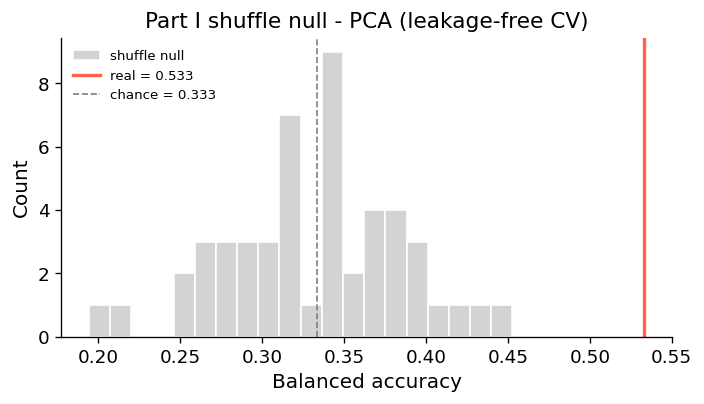

In [ ]:
rng_shuf = np.random.default_rng(seed=SEED)

null_bal = {name: [] for name, _ in cv_kinds}
null_f1  = {name: [] for name, _ in cv_kinds}

print(f"Running {N_SHUFFLES} stimulus-level shuffles")
for i in range(N_SHUFFLES):
    y_s = rng_shuf.permutation(y)
    for name, kind in cv_kinds:
        pipe = make_emb_pipeline(kind, X_raw_cv.shape[0], X_raw_cv.shape[1])
        null_bal[name].append(
            cross_val_score(pipe, X_raw_cv, y_s, cv=cv_bal,
                            scoring='balanced_accuracy').mean())
        null_f1[name].append(
            cross_val_score(pipe, X_raw_cv, y_s, cv=cv_bal,
                            scoring='f1_macro').mean())

null_bal = {k: np.array(v) for k, v in null_bal.items()}
null_f1  = {k: np.array(v) for k, v in null_f1.items()}

print("\nShuffle control results")
print(f"{'Method':<22} {'Metric':<14} {'Real':>7} {'Null mu':>9} "
      f"{'Null sd':>9} {'Null max':>9} {'p':>7}")
for name, _ in cv_kinds:
    for metric, null_arr, real_val in [
            ('Balanced acc', null_bal[name], clf_scores_bal.get(name, float('nan'))),
            ('Macro F1',     null_f1[name],  clf_scores_f1.get(name,  float('nan')))]:
        if np.isnan(real_val):
            continue
        p_emp = float((null_arr >= real_val).mean())
        sig = ('***' if p_emp < 0.001
               else '**' if p_emp < 0.01
               else '*'  if p_emp < 0.05
               else 'ns')
        print(f"  {name:<20} {metric:<14} {real_val:>7.4f} "
              f"{null_arr.mean():>9.4f} {null_arr.std():>9.4f} "
              f"{null_arr.max():>9.4f} {p_emp:>6.4f} {sig}")
    print()

if 'PCA' in null_bal and not np.isnan(clf_scores_bal.get('PCA', float('nan'))):
    fig, ax = plt.subplots(figsize=(6, 3.5))
    ax.hist(null_bal['PCA'], bins=20, color='lightgray', edgecolor='white',
            label='shuffle null')
    real_pca = clf_scores_bal['PCA']
    ax.axvline(real_pca,    color='tomato', lw=2, label=f'real = {real_pca:.3f}')
    ax.axvline(chance_level, color='gray',  ls='--', lw=1,
               label=f'chance = {chance_level:.3f}')
    ax.set_xlabel('Balanced accuracy')
    ax.set_ylabel('Count')
    ax.set_title('Part I shuffle null')
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


### Within-Clip Temporal Structure

Movielike stimulus types: [np.str_('Clip')]
running


Frame matrix: (5760, 579)  (240 unique clips)


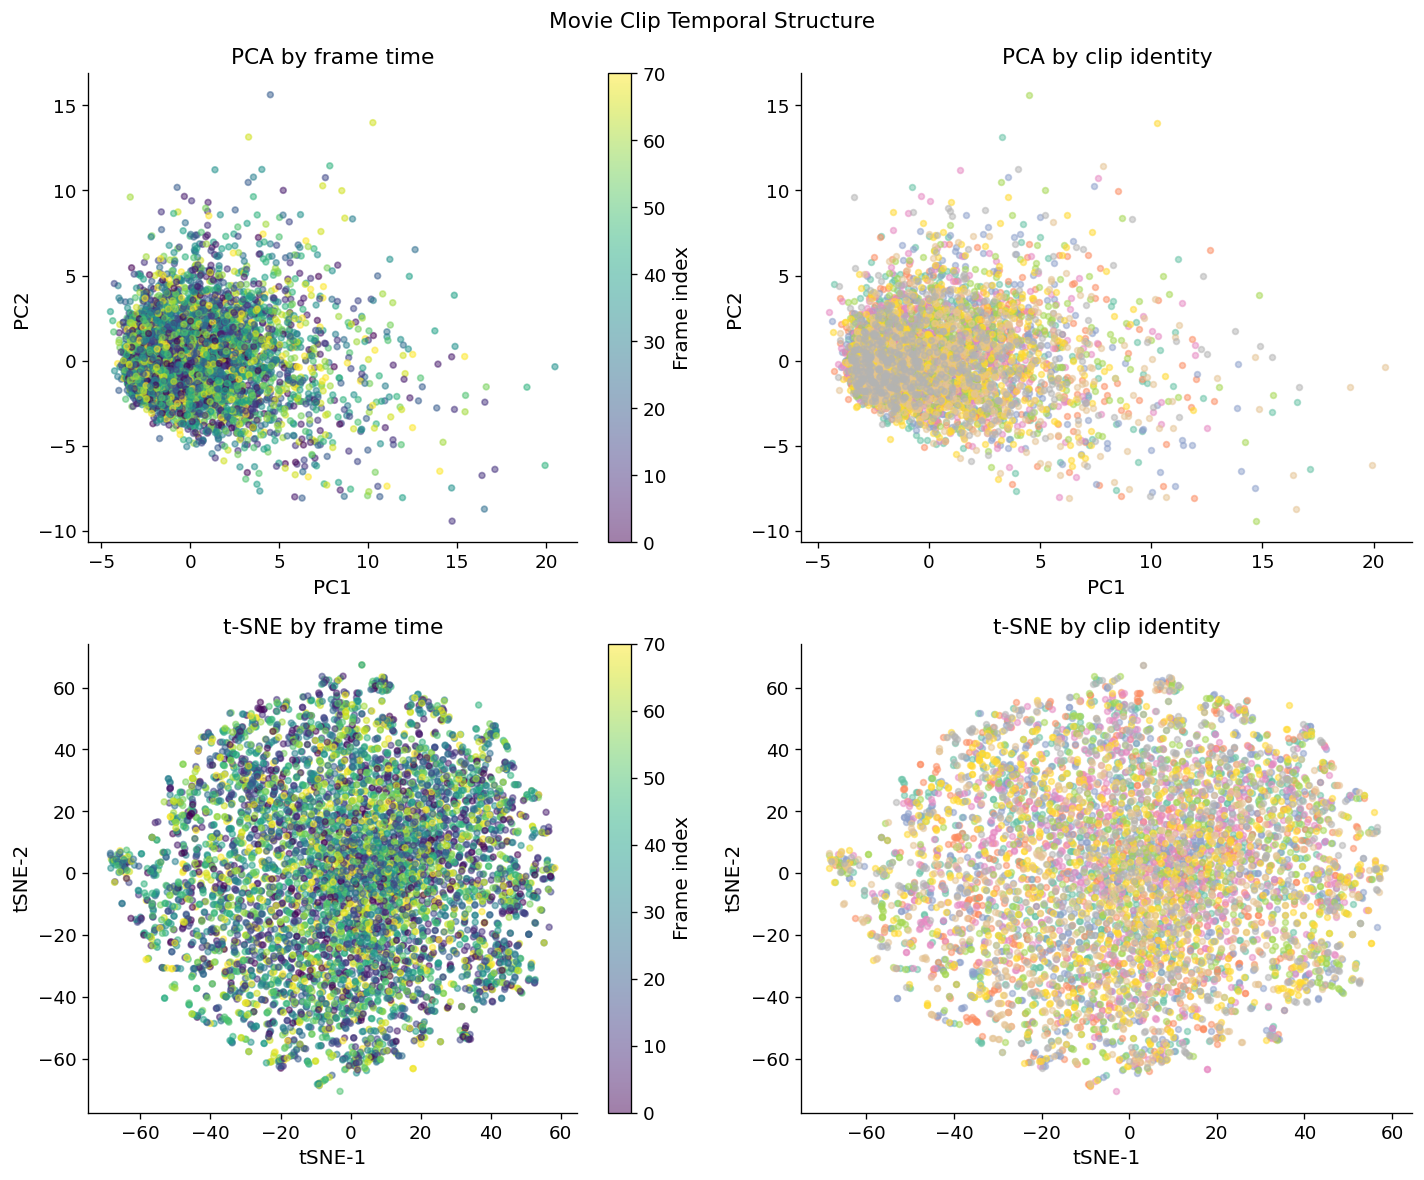

In [ ]:
movie_types = [l for l in unique_labels
               if any(kw in l.lower() for kw in ['clip','movie','natural','film'])]
if not movie_types:
    movie_types = [c for c, _ in Counter(labels).most_common(2)]
    print(f"Using: {movie_types}")
else:
    print(f"Movielike stimulus types: {movie_types}")

frame_resp, frame_time, frame_hash = [], [], []
STEP = 5

print("running")
for trial_idx, h in enumerate(hashes):
    if funcreader.get_video_type(h) not in movie_types:
        continue
    try:
        r = funcreader.get_trial(SESSION, trial_idx)
        if r is None or 'responses' not in r: continue
        resp_trusted = r['responses'][keep_neuron_cols, :]
        n_frames = resp_trusted.shape[1]
        for f in range(0, n_frames, STEP):
            frame_resp.append(resp_trusted[:, f])
            frame_time.append(f)
            frame_hash.append(h)
    except Exception:
        continue

if not frame_resp:
    print("no movie clip trials found")
else:
    RF = np.array(frame_resp)
    frame_time = np.array(frame_time)
    frame_hash = np.array(frame_hash)
    RF_clean = np.nan_to_num(RF[:, keep_neurons], nan=0.0)

    scaler_fr = StandardScaler()
    RF_scaled = scaler_fr.fit_transform(RF_clean)

    n_pca_fr = min(50, RF_scaled.shape[1] - 1, RF_scaled.shape[0] - 1)
    pca_fr = PCA(n_components=n_pca_fr, random_state=SEED)
    RF_pca = pca_fr.fit_transform(RF_scaled)

    print(f"Frame matrix: {RF_scaled.shape}  ({len(np.unique(frame_hash))} unique clips)")

    tsne_fr = TSNE(n_components=2, perplexity=20, random_state=SEED,
                   max_iter=1000, learning_rate='auto', init='pca')
    RF_tsne = tsne_fr.fit_transform(RF_pca[:, :n_pca_fr])

    unique_clips = np.unique(frame_hash)
    clip_cmap    = plt.cm.get_cmap('Set2', len(unique_clips))
    hash_to_col  = {h: clip_cmap(i) for i, h in enumerate(unique_clips)}

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    sc = axes[0,0].scatter(RF_pca[:,0], RF_pca[:,1], c=frame_time,
                           cmap='viridis', alpha=0.5, s=12)
    plt.colorbar(sc, ax=axes[0,0], label='Frame index')
    axes[0,0].set_title('PCA by frame time')
    axes[0,0].set_xlabel('PC1'); axes[0,0].set_ylabel('PC2')

    for h in unique_clips:
        m = frame_hash == h
        axes[0,1].scatter(RF_pca[m,0], RF_pca[m,1], color=hash_to_col[h], alpha=0.5, s=12)
    axes[0,1].set_title('PCA by clip identity')
    axes[0,1].set_xlabel('PC1'); axes[0,1].set_ylabel('PC2')

    sc2 = axes[1,0].scatter(RF_tsne[:,0], RF_tsne[:,1], c=frame_time,
                            cmap='viridis', alpha=0.5, s=12)
    plt.colorbar(sc2, ax=axes[1,0], label='Frame index')
    axes[1,0].set_title('t-SNE by frame time')
    axes[1,0].set_xlabel('tSNE-1'); axes[1,0].set_ylabel('tSNE-2')

    for h in unique_clips:
        m = frame_hash == h
        axes[1,1].scatter(RF_tsne[m,0], RF_tsne[m,1], color=hash_to_col[h], alpha=0.5, s=12)
    axes[1,1].set_title('t-SNE by clip identity')
    axes[1,1].set_xlabel('tSNE-1'); axes[1,1].set_ylabel('tSNE-2')

    plt.suptitle('Movie Clip Temporal Structure', fontsize=13)
    plt.tight_layout()
    plt.show()


Neuron Space Analysis

Neuron space matrix: (579, 280)


Layer breakdown:
  L1: 1
  L2/3: 220
  L4: 257
  L5: 89
  L6: 12

Type breakdown:
  excitatory_neuron: 579


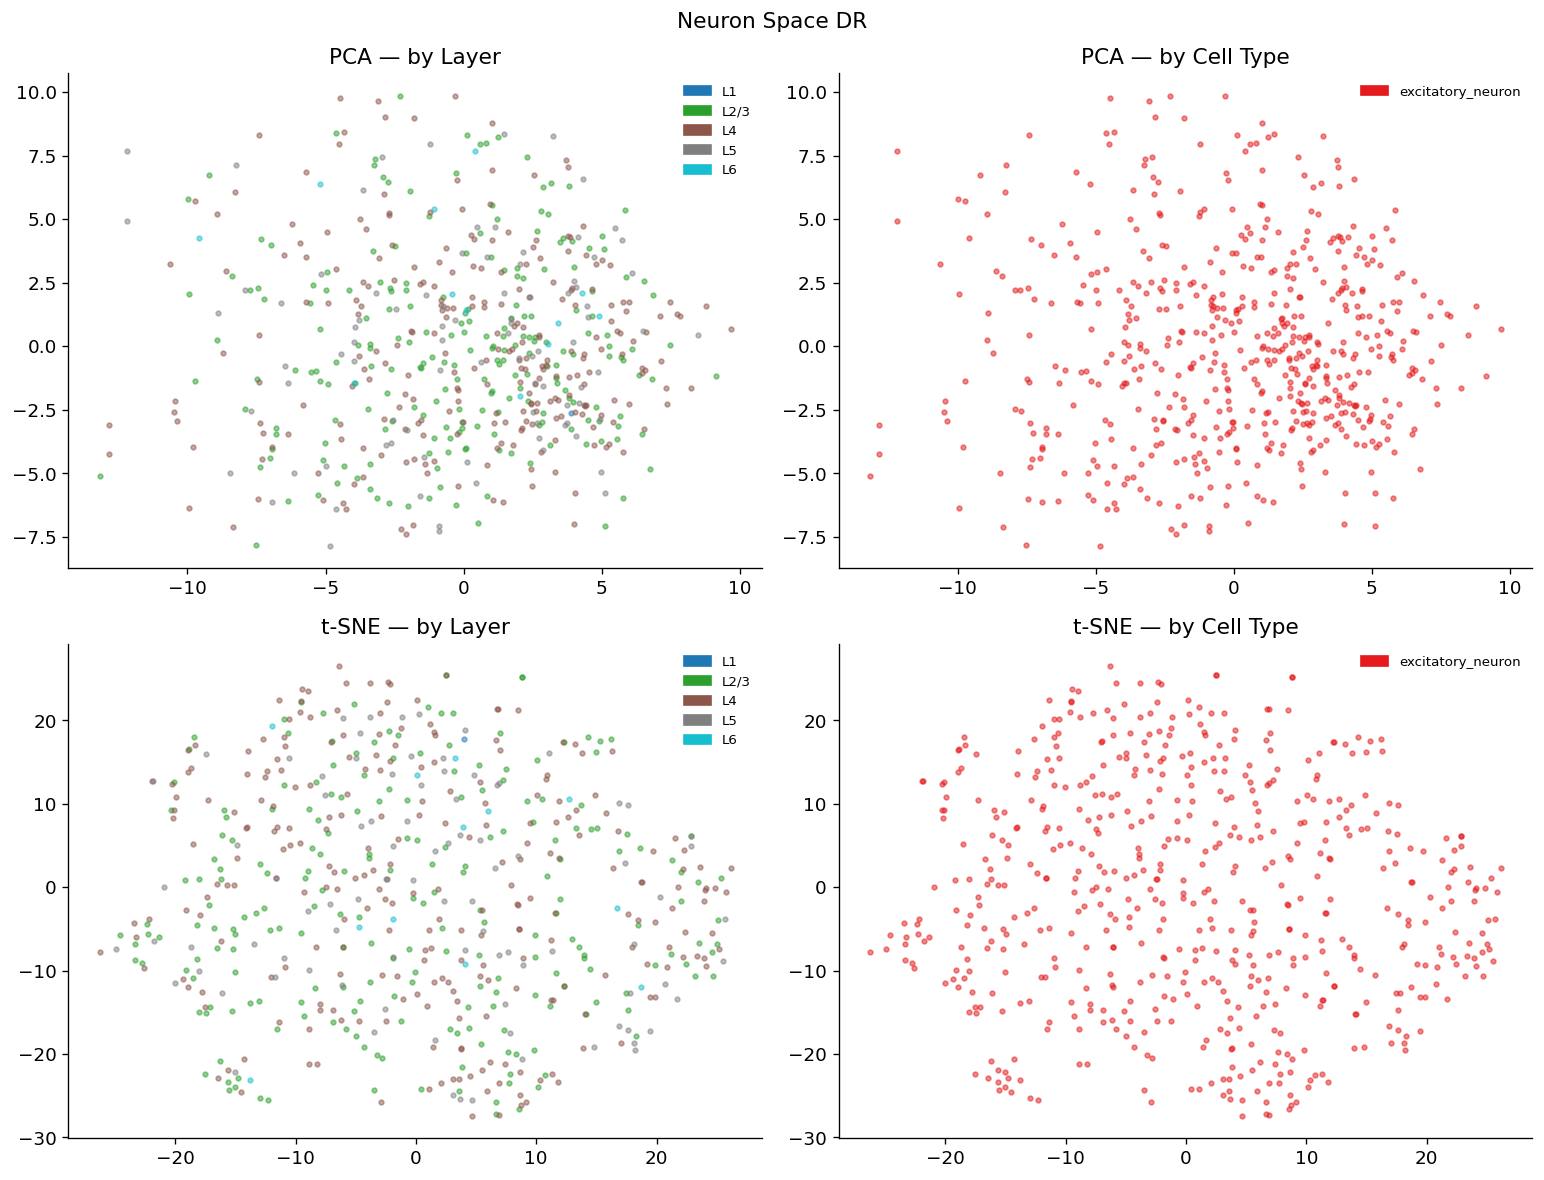

In [ ]:
R_neuron = R_scaled.T
print(f"Neuron space matrix: {R_neuron.shape}")

pca_n = PCA(n_components=min(20, R_neuron.shape[1]-1), random_state=SEED)
RN_pca = pca_n.fit_transform(R_neuron)

tsne_n = TSNE(n_components=2, perplexity=min(30, len(R_neuron)//5),
              random_state=SEED, learning_rate='auto', init='pca')
RN_tsne = tsne_n.fit_transform(RN_pca)

neuron_layer = trusted_meta_clean['layer'].fillna('unknown').values
neuron_type  = trusted_meta_clean['classification_system'].fillna('unknown').values

print(f"Layer breakdown:")
for lyr, cnt in Counter(neuron_layer).items():
    print(f"{lyr}: {cnt}")
print(f"\nType breakdown:")
for t, cnt in Counter(neuron_type).items():
    print(f"{t}: {cnt}")

LAYERS = [l for l in ['L1','L2/3','L4','L5','L6','unknown'] if l in neuron_layer]
lyr_cmap  = plt.cm.get_cmap('tab10', len(LAYERS))
lyr_color = {l: lyr_cmap(i) for i, l in enumerate(LAYERS)}
lyr_patches = [Patch(color=lyr_color[l], label=l) for l in LAYERS]

TYPES = np.unique(neuron_type)
typ_cmap  = plt.cm.get_cmap('Set1', len(TYPES))
typ_color = {t: typ_cmap(i) for i, t in enumerate(TYPES)}
typ_patches = [Patch(color=typ_color[t], label=t) for t in TYPES]

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
for row, (embedname, emb) in enumerate([('PCA', RN_pca[:,:2]), ('t-SNE', RN_tsne)]):
    for lyr in LAYERS:
        m = neuron_layer == lyr
        axes[row,0].scatter(emb[m,0], emb[m,1], color=lyr_color[lyr], alpha=0.5, s=8)
    axes[row,0].set_title(f'{embedname} — by Layer')
    axes[row,0].legend(handles=lyr_patches, markerscale=3, fontsize=8)

    for t in TYPES:
        m = neuron_type == t
        axes[row,1].scatter(emb[m,0], emb[m,1], color=typ_color[t], alpha=0.5, s=8)
    axes[row,1].set_title(f'{embedname} — by Cell Type')
    axes[row,1].legend(handles=typ_patches, markerscale=3, fontsize=8)

plt.suptitle('Neuron Space DR', fontsize=13)
plt.tight_layout()
plt.show()

### Part I Summary

In [ ]:
summary_rows = []
for name, emb in methods:
    if np.isnan(clf_scores_bal.get(name, float('nan'))):
        continue
    summary_rows.append({
        'Method': name,
        'Silhouette': f"{sil_scores.get(name, float('nan')):.4f}",
        'Std Accuracy': f"{clf_scores.get(name, float('nan')):.4f}",
        'Balanced Accuracy': f"{clf_scores_bal.get(name, float('nan')):.4f}",
        'Macro F1': f"{clf_scores_f1.get(name, float('nan')):.4f}",
    })

print('\nResults Summary')
print(pd.DataFrame(summary_rows).to_string(index=False))
print(f'\nBaselines:')
print(f'Always predict Clip (majority): {majority_frac:.4f}')
print(f'Uniform chance (balanced acc): {chance_level:.4f}')
print(f'\nIntrinsic dimensionality:')
print(f'PCs for 80% variance: {n80}')
print(f'PCs for 90% variance: {n90}')
print(f'Variance in PC1+PC2: {cumvar[1]*100:.2f}%')
print(f'Participation ratio (eff dim): {participation_ratio:.1f}')
print(f'\nNeurons used: {R_scaled.shape[1]} trusted (from {len(session_unit_ids)} recorded)')


Results Summary
      Method Silhouette Std Accuracy Balanced Accuracy Macro F1
         PCA    -0.1269       0.5857            0.5333   0.4019
UMAP (nn=15)     0.1247       0.5357            0.5750   0.3891
       CEBRA    -0.1228       0.9250            0.7653   0.7386

Baselines:
Always predict Clip (majority): 0.8571
Uniform chance (balanced acc): 0.3333

Intrinsic dimensionality:
PCs for 80% variance: 82
PCs for 90% variance: 126
Variance in PC1+PC2: 14.39%
Participation ratio (eff dim): 47.2

Neurons used: 579 trusted (from 7855 recorded)


## Part II: Temporal Bins

In [ ]:
funcreader_p2 = mic.MicronsFunctionalReader(path='microns.h5')
hashes_p2     = funcreader_p2.get_hashes_by_session(SESSION)

print(f'Trials in session: {len(hashes_p2)}')
print('Stimulus types:')
for k, v in sorted(
    Counter(funcreader_p2.get_video_type(h) for h in hashes_p2).items(),
    key=lambda x: -x[1]):
    print(f'{k:22s}: {v:4d}')


Trials in session: 464
Stimulus types:
  Clip                  :  384
  Monet2                :   40
  Trippy                :   40


In [ ]:
bins_resp, bins_type, bins_hash, bins_trial, bins_t = [], [], [], [], []
n_failed_p2  = 0
n_trials_p2  = 0

print(f'Extracting bins (BIN_SIZE={BIN_SIZE} frames)')
for trial_idx, h in enumerate(hashes_p2):
    stype = funcreader_p2.get_video_type(h)
    try:
        r = funcreader_p2.get_trial(SESSION, trial_idx)
        if r is None or 'responses' not in r:
            n_failed_p2 += 1; continue
        resp    = r['responses'][keep_neuron_cols, :]
        n_frames = resp.shape[1]
        n_bins   = n_frames // BIN_SIZE
        if n_bins < MIN_BINS:
            continue
        binned = (
            resp[:, :n_bins * BIN_SIZE]
            .reshape(resp.shape[0], n_bins, BIN_SIZE)
            .mean(axis=2)
            .T
        )
        for b in range(n_bins):
            bins_resp.append(binned[b])
            bins_type.append(stype)
            bins_hash.append(h)
            bins_trial.append(trial_idx)
            bins_t.append(b)
        n_trials_p2 += 1
    except Exception:
        n_failed_p2 += 1

R_matrix_p2   = np.array(bins_resp)
labels_raw_p2 = np.array(bins_type)
hash_ids_p2   = np.array(bins_hash)
trial_ids     = np.array(bins_trial)
time_idx      = np.array(bins_t)

print(f'\nTrials used:{n_trials_p2}  (skipped:{n_failed_p2})')
print(f'Total bins:{len(R_matrix_p2)}')
print(f'R_matrix shape: {R_matrix_p2.shape}')
print('\nBins per stimulus type:')
for k, v in sorted(Counter(labels_raw_p2).items(), key=lambda x: -x[1]):
    print(f'{k:22s}: {v:5d}')


Extracting bins (BIN_SIZE=5 frames)...



Trials used:    464  (skipped: 0)
Total bins:     7520
R_matrix shape: (7520, 579)

Bins per stimulus type:
  Clip                  :  5760
  Monet2                :   880
  Trippy                :   880


### Preprocessing

In [ ]:
nan_frac_p2 = np.isnan(R_matrix_p2).mean(axis=0)
keep_neurons_p2 = nan_frac_p2 < 0.10

R_clean_p2 = R_matrix_p2[:, keep_neurons_p2].copy()
trusted_meta_p2 = trusted_meta[keep_neurons_p2].reset_index(drop=True)

print(f'Neurons retained: {keep_neurons_p2.sum()} / {R_matrix_p2.shape[1]}')

active_p2   = np.nanstd(R_clean_p2, axis=1) > 1e-6
R_clean_p2  = R_clean_p2[active_p2]
labels_p2   = labels_raw_p2[active_p2]
hash_ids_p2 = hash_ids_p2[active_p2]
trial_ids   = trial_ids[active_p2]
time_idx    = time_idx[active_p2]

print(f'Bins after activity filter: {active_p2.sum()} / {len(active_p2)}')

viz_imp  = SimpleImputer(strategy='mean')
viz_sc   = StandardScaler()
R_viz_p2    = viz_imp.fit_transform(R_clean_p2)
R_scaled_p2 = viz_sc.fit_transform(R_viz_p2)

print(f'\nFinal feature matrix: {R_clean_p2.shape}')


Neurons retained: 579 / 579
Bins after activity filter: 7520 / 7520

Final feature matrix  (modeling): (7520, 579)
Visualisation matrix (full-data): (7520, 579)


In [ ]:
unique_labels_p2 = sorted(set(labels_p2))
n_types_p2 = len(unique_labels_p2)
palette_p2 = plt.cm.get_cmap('tab10', n_types_p2)
label_to_color_p2 = {lbl: palette_p2(i) for i, lbl in enumerate(unique_labels_p2)}
le_p2 = LabelEncoder()
y_p2 = le_p2.fit_transform(labels_p2)
counts_p2 = {lbl: int((labels_p2 == lbl).sum()) for lbl in unique_labels_p2}
majority_frac_p2 = max(counts_p2.values()) / len(labels_p2)
chance_level_p2 = 1.0 / n_types_p2
legend_patches_p2 = [Patch(color=label_to_color_p2[l], label=l)
                     for l in unique_labels_p2]

print(f'Classes: {n_types_p2}, chance = {chance_level_p2:.3f},  '
      f'majority = {majority_frac_p2:.3f}')
for lbl, n in counts_p2.items():
    print(f'  {lbl:22s}  n={n:5d}  ({100*n/len(labels_p2):.1f}%)')
print(f'\nUnique trials: {len(np.unique(trial_ids))}')


Classes: 3  |  chance = 0.333  |  majority = 0.766
  Clip                    n= 5760  (76.6%)
  Monet2                  n=  880  (11.7%)
  Trippy                  n=  880  (11.7%)

Unique trials: 464  (used as CV groups)


In [ ]:
R_scaled      = R_scaled_p2
labels        = labels_p2
y             = y_p2
unique_labels = unique_labels_p2
label_to_color = label_to_color_p2
le             = le_p2
legend_patches = legend_patches_p2
chance_level   = chance_level_p2

### PCA

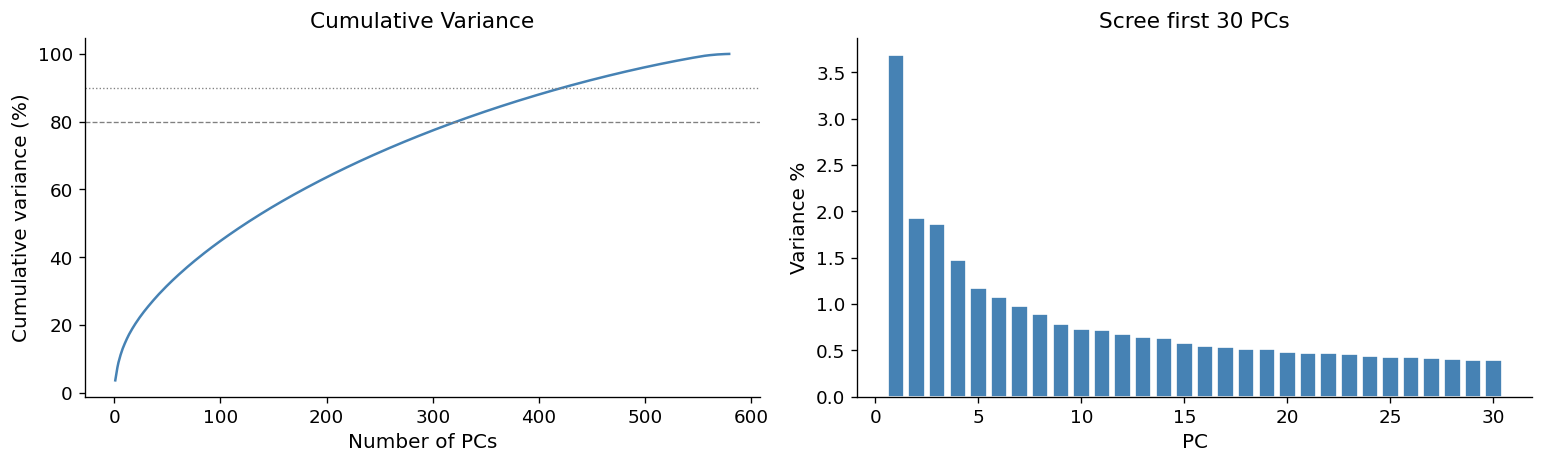

PCs for 80% var: 322   PCs for 90% var: 422
PC1+PC2: 5.62%
Participation ratio: 212.0
Total variance explained by full fitted spectrum: 100.00%


In [ ]:
pca = PCA(n_components=None, svd_solver='full')
R_pca = pca.fit_transform(R_scaled)

ev = pca.explained_variance_ratio_
cumvar = np.cumsum(ev)
n_pcs = len(ev)

participation_ratio = 1.0 / np.sum(ev ** 2)

def pcs_needed(cumvar, threshold):
    if cumvar[-1] < threshold:
        return f'>{len(cumvar)}'
    return str(int(np.searchsorted(cumvar, threshold) + 1))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(np.arange(1, n_pcs + 1), cumvar * 100, color='steelblue')
axes[0].set_xlabel('Number of PCs')
axes[0].set_ylabel('Cumulative variance (%)')
axes[0].axhline(80, color='gray', ls='--', lw=0.8)
axes[0].axhline(90, color='gray', ls=':',  lw=0.8)
axes[0].set_title('Cumulative Variance')

n_show = min(30, n_pcs)
axes[1].bar(
    np.arange(1, n_show + 1),
    ev[:n_show] * 100,
    color='steelblue',
    edgecolor='white',
)
axes[1].set_xlabel('PC')
axes[1].set_ylabel('Variance %')
axes[1].set_title(f'Scree first {n_show} PCs')

plt.tight_layout()
plt.savefig('fig_ts_pca_variance.png', dpi=150)
plt.show()

n80 = pcs_needed(cumvar, 0.80)
n90 = pcs_needed(cumvar, 0.90)

pc12 = cumvar[min(1, len(cumvar) - 1)] * 100

print(f'PCs for 80% var: {n80}   PCs for 90% var: {n90}')
print(f'PC1+PC2: {pc12:.2f}%')
print(f'Participation ratio: {participation_ratio:.1f}')
print(f'Total variance explained by full fitted spectrum: {cumvar[-1] * 100:.2f}%')


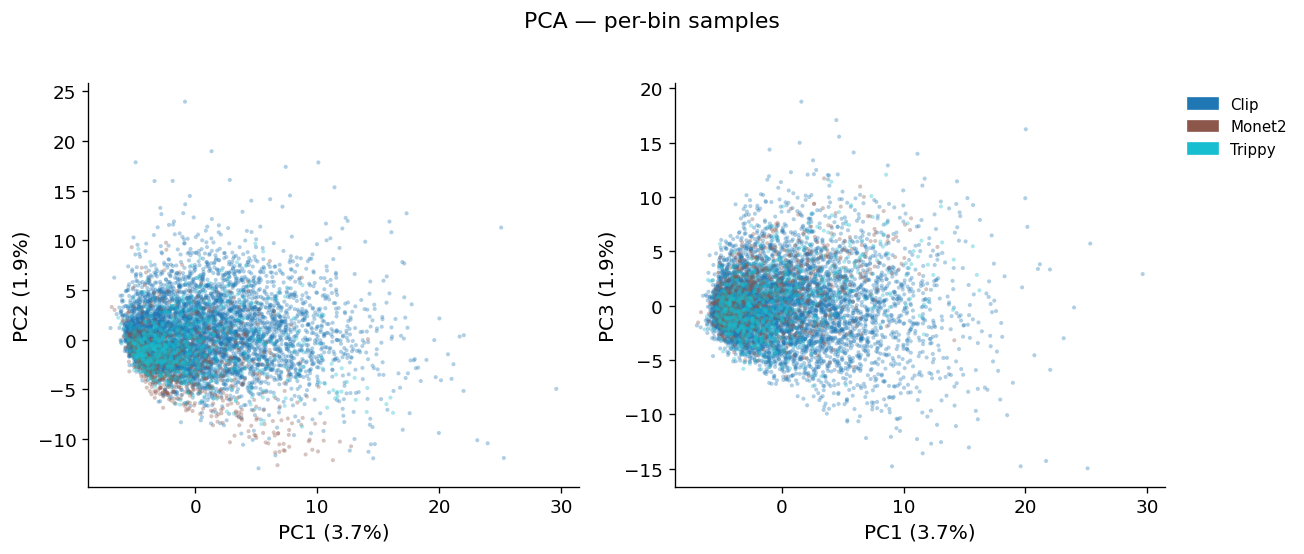

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for xi, yi, ax in [(0,1,axes[0]), (0,2,axes[1])]:
    for lbl in unique_labels:
        m = labels == lbl
        ax.scatter(R_pca[m,xi], R_pca[m,yi],
                   color=label_to_color[lbl], alpha=0.35, s=6, edgecolors='none')
    ax.set_xlabel(f'PC{xi+1} ({ev[xi]*100:.1f}%)')
    ax.set_ylabel(f'PC{yi+1} ({ev[yi]*100:.1f}%)')
axes[1].legend(handles=legend_patches, bbox_to_anchor=(1.02,1), loc='upper left', fontsize=9)
plt.suptitle('PCA — per-bin samples', y=1.02)
plt.tight_layout()
plt.show()


### t-SNE and UMAP

In [30]:
rng = np.random.default_rng(SEED)
SUB_N = min(8000, len(R_pca))
sub_idx = rng.choice(len(R_pca), size=SUB_N, replace=False)
sub_idx.sort()

R_pca_sub  = R_pca[sub_idx, :N_PCS_FOR_TSNE]
labels_sub = labels[sub_idx]
y_sub      = y[sub_idx]

tsne = TSNE(n_components=2, perplexity=30, random_state=SEED,
            max_iter=1000, learning_rate='auto', init='pca')
R_tsne = tsne.fit_transform(R_pca_sub)

R_umap = None
if UMAP_AVAILABLE:
    R_umap = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.1,
                       random_state=SEED).fit_transform(R_pca_sub)


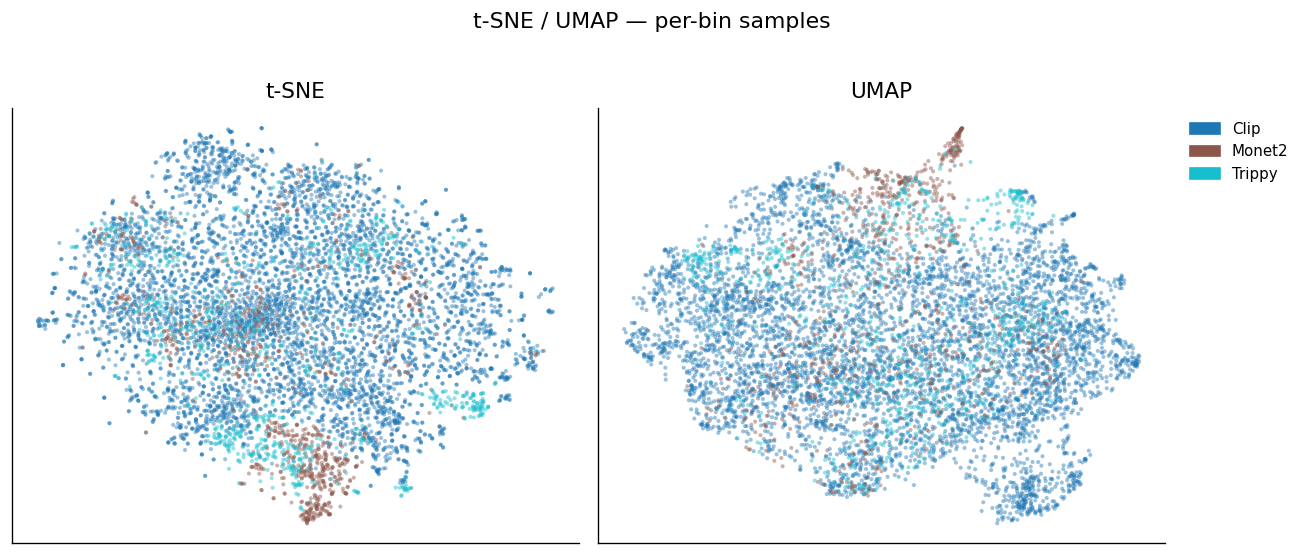

In [ ]:
fig, axes = plt.subplots(1, 2 if R_umap is not None else 1,
                         figsize=(11 if R_umap is not None else 6, 4.5))
if R_umap is None: axes = [axes]
for ax, name, emb in [(axes[0], 't-SNE', R_tsne)] + (
    [(axes[1], 'UMAP', R_umap)] if R_umap is not None else []):
    for lbl in unique_labels:
        m = labels_sub == lbl
        ax.scatter(emb[m,0], emb[m,1], color=label_to_color[lbl],
                   alpha=0.45, s=6, edgecolors='none')
    ax.set_title(name); ax.set_xticks([]); ax.set_yticks([])
axes[-1].legend(handles=legend_patches, bbox_to_anchor=(1.02,1), loc='upper left', fontsize=9)
plt.suptitle('t-SNE / UMAP — per-bin samples', y=1.02)
plt.tight_layout()
plt.show()


### CEBRA

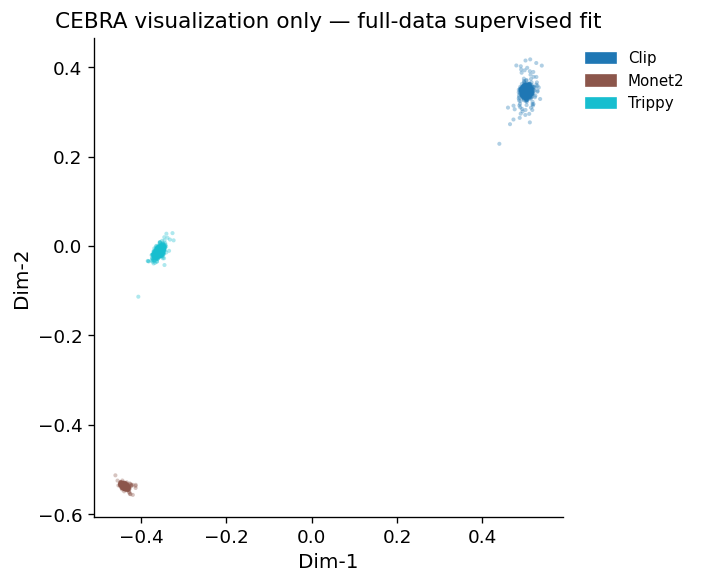

In [ ]:
R_cebra_viz = None

CEBRA_PARAMS = dict(
    model_architecture='offset10-model',
    batch_size=512,
    learning_rate=3e-4,
    temperature=1.0,
    output_dimension=8,
    max_iterations=4000,
    distance='cosine',
    conditional='discrete',
    device='cpu',
    verbose=False,
)

if CEBRA_AVAILABLE:
    try:
        order = np.lexsort((time_idx, trial_ids))
        R_ordered = R_scaled[order].astype(np.float32)
        y_ordered = y[order].astype(np.int64)

        cb_viz = cebra.CEBRA(**CEBRA_PARAMS)
        cb_viz.fit(R_ordered, y_ordered)

        R_cebra_ord = cb_viz.transform(R_ordered)

        inv = np.empty_like(order)
        inv[order] = np.arange(len(order))
        R_cebra_viz = R_cebra_ord[inv]

        fig, ax = plt.subplots(figsize=(6, 5))
        for lbl in unique_labels:
            m = labels == lbl
            ax.scatter(
                R_cebra_viz[m, 0],
                R_cebra_viz[m, 1],
                color=label_to_color[lbl],
                alpha=0.35,
                s=6,
                edgecolors='none',
            )

        ax.set_title('CEBRA visualization only — full-data supervised fit')
        ax.set_xlabel('Dim-1')
        ax.set_ylabel('Dim-2')
        ax.legend(
            handles=legend_patches,
            bbox_to_anchor=(1.02, 1),
            loc='upper left',
            fontsize=9,
        )

        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f'CEBRA visualization failed: {e}')
        R_cebra_viz = None
else:
    print('CEBRA not installed')

In [ ]:
cv_groups_p2 = hash_ids_p2

_unique_per_class = {
    cls: len(np.unique(cv_groups_p2[y_p2 == cls]))
    for cls in np.unique(y_p2)
}
print('Unique hashes per class:', _unique_per_class)

if min(_unique_per_class.values()) >= N_CV_SPLITS:
    gkf = StratifiedGroupKFold(
        n_splits=N_CV_SPLITS, shuffle=True, random_state=SEED,
    )
    print(f'Using StratifiedGroupKFold(n_splits={N_CV_SPLITS}) grouped by hash')
else:
    gkf = GroupKFold(n_splits=N_CV_SPLITS)
    print(f'WARNING: some class has < {N_CV_SPLITS} unique hashes'
          f'falling back to  GroupKFold')


def make_logreg():
    return LogisticRegression(
        max_iter=2000, C=1.0, random_state=SEED,
        class_weight='balanced',
    )


def make_pca_logreg_pipeline(n_components):
    return Pipeline([
        ('impute', SimpleImputer(strategy='mean')),
        ('scale', StandardScaler()),
        ('pca', PCA(n_components=n_components, random_state=SEED)),
        ('clf', make_logreg()),
    ])


def evaluate_sklearn_model_cv(name, model, X, y_arr, groups):
    bal = cross_val_score(
        model, X, y_arr, cv=gkf, groups=groups,
        scoring='balanced_accuracy', n_jobs=-1,
    )
    f1 = cross_val_score(
        model, X, y_arr, cv=gkf, groups=groups,
        scoring='f1_macro', n_jobs=-1,
    )
    y_pred = cross_val_predict(
        model, X, y_arr, cv=gkf, groups=groups, n_jobs=-1,
    )
    print(
        f'{name:14s}  bal_acc = {bal.mean():.4f} +/- {bal.std():.4f}'
        f'F1 = {f1.mean():.4f} +/- {f1.std():.4f}'
    )
    return {'bal': bal, 'f1': f1, 'y_pred': y_pred}


CEBRA_PARAMS = dict(
    model_architecture='offset10-model',
    batch_size=512,
    learning_rate=3e-4,
    temperature=1.0,
    output_dimension=8,
    max_iterations=4000,
    distance='cosine',
    conditional='discrete',
    device='cpu',
    verbose=False,
)


def evaluate_cebra_groupcv(X_raw, y_arr, cv_groups, trial_groups, t_idx):
    y_pred   = np.full_like(y_arr, fill_value=-1)
    fold_bal = []
    fold_f1  = []
    splits   = list(gkf.split(X_raw, y_arr, groups=cv_groups))

    for fold_i, (tr_idx, te_idx) in enumerate(splits, start=1):
        print(f'  CEBRA fold {fold_i}/{len(splits)}')
        imp  = SimpleImputer(strategy='mean')
        sc   = StandardScaler()
        X_tr = sc.fit_transform(imp.fit_transform(X_raw[tr_idx])).astype(np.float32)
        X_te = sc.transform(imp.transform(X_raw[te_idx])).astype(np.float32)
        y_tr = y_arr[tr_idx].astype(np.int64)
        y_te = y_arr[te_idx].astype(np.int64)

        order_tr = np.lexsort((t_idx[tr_idx], trial_groups[tr_idx]))
        order_te = np.lexsort((t_idx[te_idx], trial_groups[te_idx]))
        inv_tr   = np.argsort(order_tr)
        inv_te   = np.argsort(order_te)

        X_tr_sorted = X_tr[order_tr]
        y_tr_sorted = y_tr[order_tr]
        X_te_sorted = X_te[order_te]

        cb = cebra.CEBRA(**CEBRA_PARAMS)
        cb.fit(X_tr_sorted, y_tr_sorted)

        Z_tr = cb.transform(X_tr_sorted)[inv_tr]
        Z_te = cb.transform(X_te_sorted)[inv_te]

        clf_fold = make_logreg()
        clf_fold.fit(Z_tr, y_tr)
        pred = clf_fold.predict(Z_te)
        y_pred[te_idx] = pred

        fold_bal.append(balanced_accuracy_score(y_te, pred))
        fold_f1.append(f1_score(y_te, pred, average='macro'))

    if np.any(y_pred < 0):
        raise RuntimeError('Some samples did not get CEBRA predictions')
    return {'bal': np.array(fold_bal), 'f1': np.array(fold_f1), 'y_pred': y_pred}


def evaluate_umap_groupcv(X_raw, y_arr, cv_groups, t_idx=None,
                          trial_groups=None):
    if not UMAP_AVAILABLE:
        return None

    y_pred   = np.full_like(y_arr, fill_value=-1)
    fold_bal = []
    fold_f1  = []
    splits   = list(gkf.split(X_raw, y_arr, groups=cv_groups))

    for fold_i, (tr_idx, te_idx) in enumerate(splits, start=1):
        print(f'  UMAP fold {fold_i}/{len(splits)}')
        imp     = SimpleImputer(strategy='mean')
        sc      = StandardScaler()
        pca_pre = PCA(n_components=N_PCS_FOR_TSNE, random_state=SEED)

        X_tr = sc.fit_transform(imp.fit_transform(X_raw[tr_idx]))
        X_te = sc.transform(imp.transform(X_raw[te_idx]))

        X_tr_pca = pca_pre.fit_transform(X_tr)
        X_te_pca = pca_pre.transform(X_te)

        reducer = umap.UMAP(
            n_components=2, n_neighbors=30, min_dist=0.1,
            random_state=SEED,
        )
        Z_tr = reducer.fit_transform(X_tr_pca)
        Z_te = reducer.transform(X_te_pca)

        clf_fold = make_logreg()
        clf_fold.fit(Z_tr, y_arr[tr_idx])
        pred = clf_fold.predict(Z_te)
        y_pred[te_idx] = pred

        fold_bal.append(balanced_accuracy_score(y_arr[te_idx], pred))
        fold_f1.append(f1_score(y_arr[te_idx], pred, average='macro'))

    if np.any(y_pred < 0):
        raise RuntimeError('Some samples did not get UMAP predictions')
    return {'bal': np.array(fold_bal), 'f1': np.array(fold_f1), 'y_pred': y_pred}

Unique hashes per class: {np.int64(0): 240, np.int64(1): 20, np.int64(2): 20}
Using StratifiedGroupKFold(n_splits=5) grouped by hash.


In [ ]:
models_p2 = {
    'PCA-2D':              make_pca_logreg_pipeline(2),
    f'PCA-{N_PCS_FOR_CLF}D': make_pca_logreg_pipeline(N_PCS_FOR_CLF),
}

cv_results_p2 = {}

print('Cross validated balanced accuracy')
print(f'chance={chance_level_p2:.3f}   majority={majority_frac_p2:.3f}\n')

for name, model in models_p2.items():
    cv_results_p2[name] = evaluate_sklearn_model_cv(
        name=name, model=model,
        X=R_clean_p2, y_arr=y_p2, groups=cv_groups_p2,
    )

if UMAP_AVAILABLE:
    try:
        print('\nRunning fold-local UMAP evaluation')
        umap_result = evaluate_umap_groupcv(
            R_clean_p2, y_p2,
            cv_groups=cv_groups_p2, t_idx=time_idx, trial_groups=trial_ids,
        )
        if umap_result is not None:
            cv_results_p2['UMAP-2D'] = umap_result
            bal = umap_result['bal']; f1 = umap_result['f1']
            print(
                f'{"UMAP-2D":14s}  bal_acc = {bal.mean():.4f} '
                f'+/- {bal.std():.4f}   F1 = {f1.mean():.4f} '
                f'+/- {f1.std():.4f}'
            )
    except Exception as e:
        print(f'UMAP evaluation failed: {e}')
else:
    print('Skipping UMAP evaluation')

if CEBRA_AVAILABLE:
    try:
        print('\nRunning fold-local CEBRA evaluation')
        cebra_result = evaluate_cebra_groupcv(
            R_clean_p2, y_p2,
            cv_groups=cv_groups_p2, trial_groups=trial_ids, t_idx=time_idx,
        )
        cv_results_p2['CEBRA-8D'] = cebra_result
        bal = cebra_result['bal']; f1 = cebra_result['f1']
        print(
            f'{"CEBRA-8D":14s}  bal_acc = {bal.mean():.4f} '
            f'+/- {bal.std():.4f}   F1 = {f1.mean():.4f} '
            f'+/- {f1.std():.4f}'
        )
    except Exception as e:
        print(f'CEBRA evaluation failed: {e}')
else:
    print('Skipping CEBRA evaluation')

scores_p2 = {
    name: (
        res['bal'].mean(), res['bal'].std(),
        res['f1'].mean(),  res['f1'].std(),
    )
    for name, res in cv_results_p2.items()
}
predictions_p2 = {name: res['y_pred'] for name, res in cv_results_p2.items()}

Cross-validated balanced accuracy - hash-grouped, stratified CV
  chance=0.333   majority=0.766



  PCA-2D          bal_acc = 0.4810 +/- 0.0632   F1 = 0.3636 +/- 0.0543


  PCA-50D         bal_acc = 0.8222 +/- 0.0637   F1 = 0.7136 +/- 0.0457

Running fold-local UMAP evaluation...
  UMAP fold 1/5


  UMAP fold 2/5


  UMAP fold 3/5


...

  CEBRA fold 2/5


  CEBRA fold 3/5


  CEBRA fold 4/5


  CEBRA fold 5/5


  CEBRA-8D        bal_acc = 0.8986 +/- 0.0333   F1 = 0.8672 +/- 0.0226


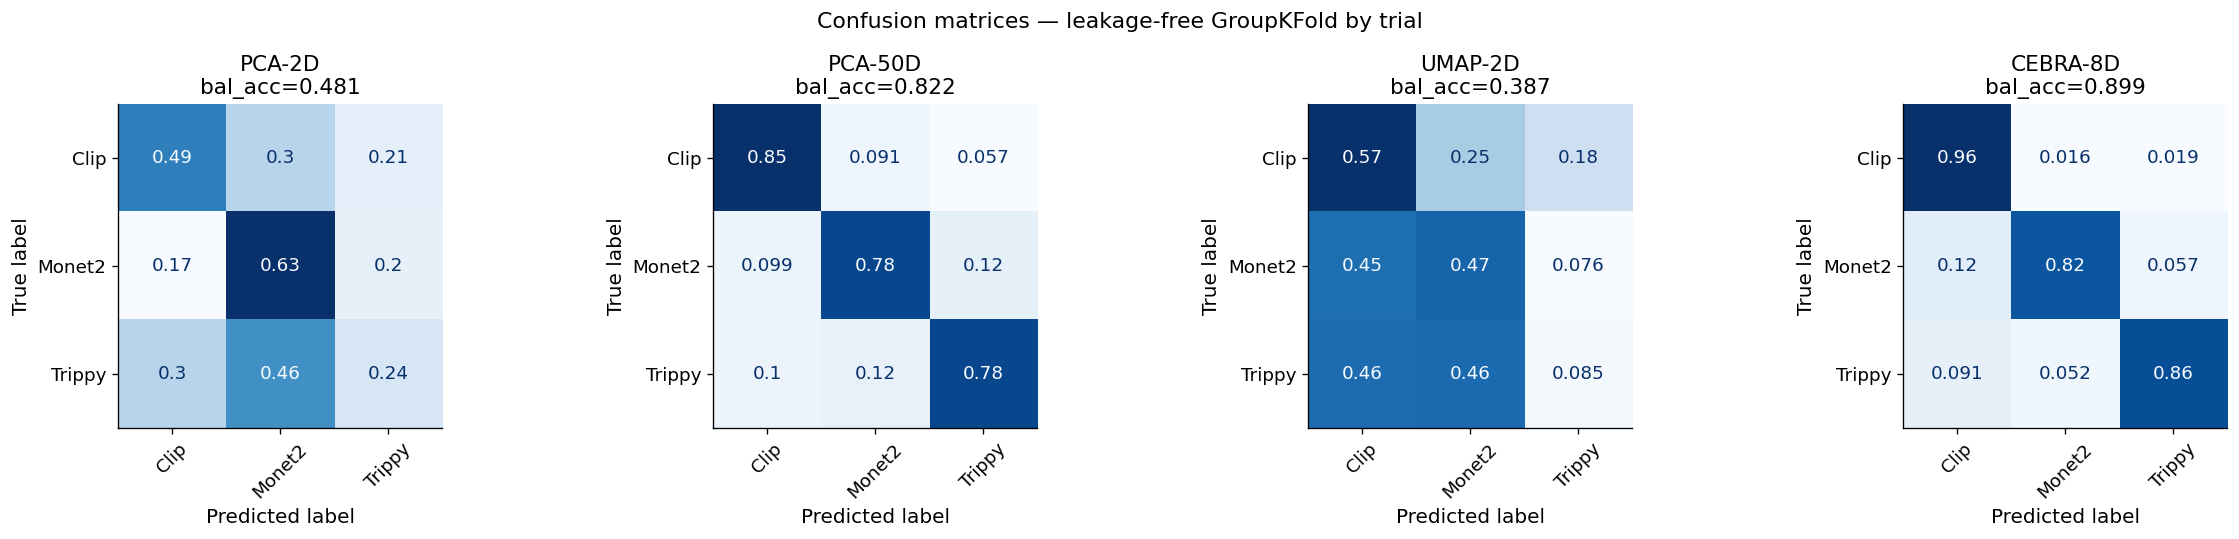

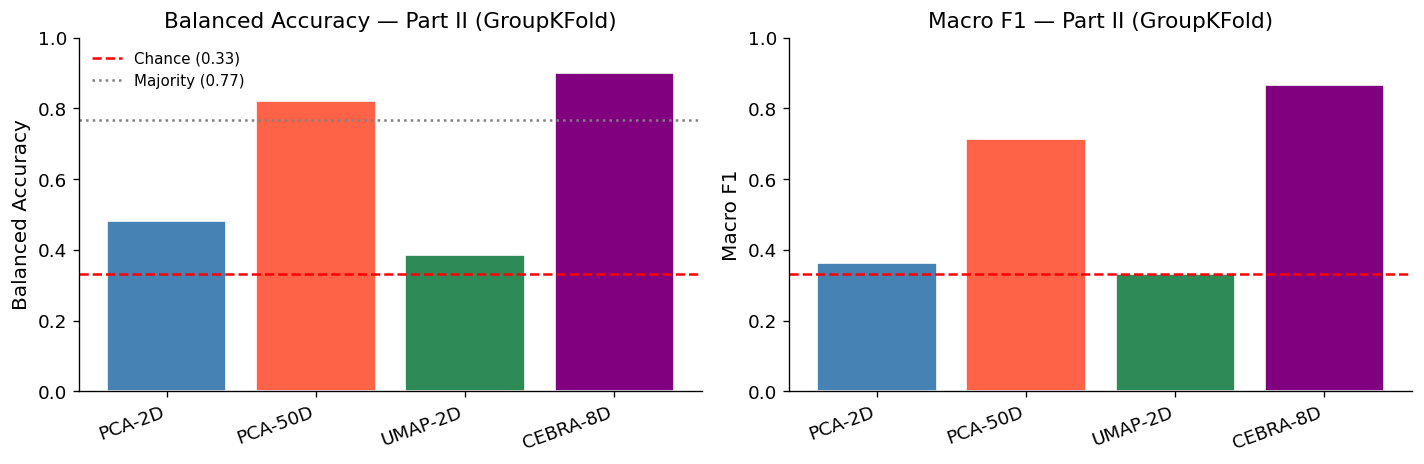

In [35]:
n_models = len(predictions_p2)
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 4.5))
axes = np.atleast_1d(axes)

for ax, (name, y_pred) in zip(axes, predictions_p2.items()):
    cm_arr = confusion_matrix(y_p2, y_pred, normalize='true')
    ConfusionMatrixDisplay(cm_arr, display_labels=le_p2.classes_).plot(
        ax=ax, colorbar=False, cmap='Blues', xticks_rotation=45,
    )
    bacc = scores_p2[name][0]
    ax.set_title(f'{name}\nbal_acc={bacc:.3f}')

plt.suptitle('Confusion matrices — leakage-free GroupKFold by trial')
plt.tight_layout()
plt.savefig('fig_ts_confusion_leakage_free.png', dpi=150)
plt.show()

# Summary bar chart
method_names = list(scores_p2.keys())
bal_vals  = [scores_p2[n][0] for n in method_names]
f1_vals   = [scores_p2[n][2] for n in method_names]
colors_p2 = ['steelblue', 'tomato', 'seagreen', 'purple'][:len(method_names)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(method_names, bal_vals, color=colors_p2, edgecolor='white')
axes[0].axhline(chance_level_p2, color='red',  ls='--',
                label=f'Chance ({chance_level_p2:.2f})')
axes[0].axhline(majority_frac_p2, color='gray', ls=':',
                label=f'Majority ({majority_frac_p2:.2f})')
axes[0].set_ylabel('Balanced Accuracy'); axes[0].set_ylim(0, 1)
axes[0].set_title('Balanced Accuracy — Part II (GroupKFold)')
axes[0].set_xticklabels(method_names, rotation=20, ha='right')
axes[0].legend(fontsize=9)

axes[1].bar(method_names, f1_vals, color=colors_p2, edgecolor='white')
axes[1].axhline(chance_level_p2, color='red', ls='--')
axes[1].set_ylabel('Macro F1'); axes[1].set_ylim(0, 1)
axes[1].set_title('Macro F1 — Part II (GroupKFold)')
axes[1].set_xticklabels(method_names, rotation=20, ha='right')

plt.tight_layout()
plt.show()


### Shuffle Control

Running 50 hash-level shuffles...


Real bal_acc      : 0.8222
Null mean +/- sd  : 0.3336 +/- 0.0306
Null max          : 0.3922
Empirical p       : 0.0000  (N_SHUFFLES=50)


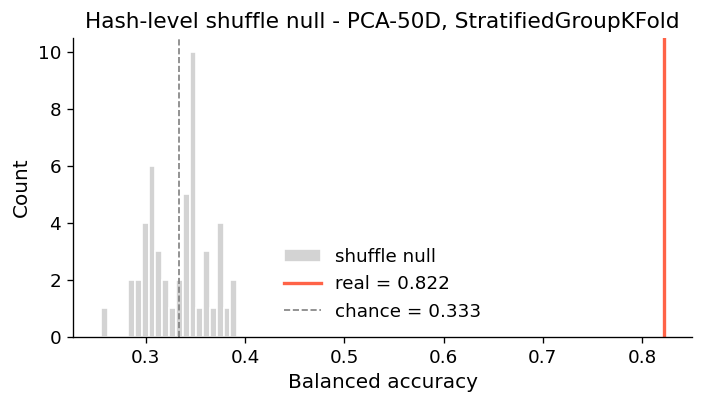

In [ ]:
unique_hashes   = np.unique(hash_ids_p2)
hash_to_y_p2   = {h: y_p2[hash_ids_p2 == h][0] for h in unique_hashes}
real_bal_p2     = scores_p2[f'PCA-{N_PCS_FOR_CLF}D'][0]

null_bal_p2 = []
rng_s_p2    = np.random.default_rng(SEED)

print(f'Running {N_SHUFFLES} hash-level shuffles')
for i in range(N_SHUFFLES):
    shuf_per_hash = rng_s_p2.permutation(
        [hash_to_y_p2[h] for h in unique_hashes]
    )
    h2ys   = dict(zip(unique_hashes, shuf_per_hash))
    y_shuf = np.array([h2ys[h] for h in hash_ids_p2])

    bal = cross_val_score(
        make_pca_logreg_pipeline(N_PCS_FOR_CLF),
        R_clean_p2, y_shuf,
        cv=gkf, groups=cv_groups_p2,
        scoring='balanced_accuracy', n_jobs=-1,
    ).mean()
    null_bal_p2.append(bal)

null_bal_p2 = np.array(null_bal_p2)

print(f'Real bal_acc: {real_bal_p2:.4f}')
print(f'Null mean +/- sd: {null_bal_p2.mean():.4f} +/- {null_bal_p2.std():.4f}')
print(f'Null max: {null_bal_p2.max():.4f}')
p_emp = (null_bal_p2 >= real_bal_p2).mean()
print(f'Empirical p: {p_emp:.4f}  (N_SHUFFLES={N_SHUFFLES})')

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(null_bal_p2, bins=20, color='lightgray', edgecolor='white',
        label='shuffle null')
ax.axvline(real_bal_p2,     color='tomato', lw=2,
           label=f'real = {real_bal_p2:.3f}')
ax.axvline(chance_level_p2, color='gray',   ls='--', lw=1,
           label=f'chance = {chance_level_p2:.3f}')
ax.set_xlabel('Balanced accuracy')
ax.set_ylabel('Count')
ax.set_title(f'Hash-level shuffle null - PCA-{N_PCS_FOR_CLF}D, StratifiedGroupKFold')
ax.legend()
plt.tight_layout()
plt.savefig('fig_ts_shuffle_leakage_free.png', dpi=150)
plt.show()

### Within-Trial Temporal Structure

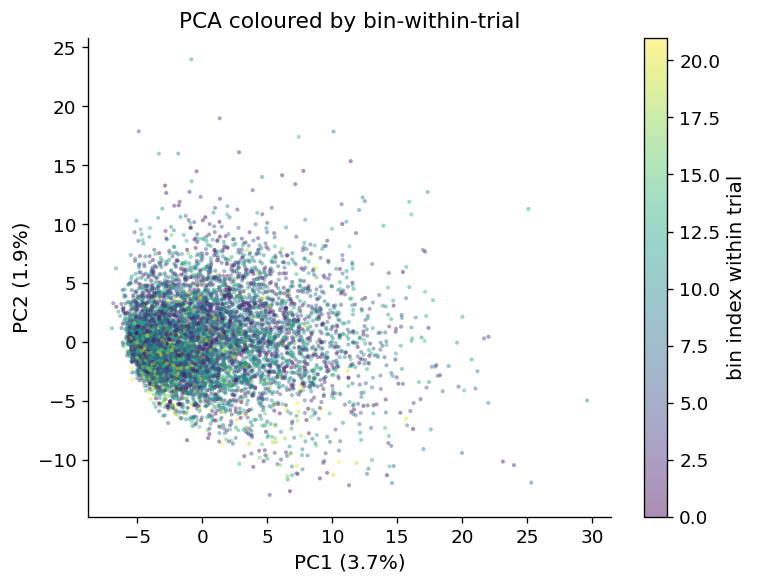

In [37]:
fig, ax = plt.subplots(figsize=(6.5, 5))
sc = ax.scatter(R_pca[:,0], R_pca[:,1], c=time_idx, cmap='viridis',
                alpha=0.45, s=6, edgecolors='none')
plt.colorbar(sc, ax=ax, label='bin index within trial')
ax.set_xlabel(f'PC1 ({ev[0]*100:.1f}%)'); ax.set_ylabel(f'PC2 ({ev[1]*100:.1f}%)')
ax.set_title('PCA coloured by bin-within-trial')
plt.tight_layout()
plt.show()


### Layer-Specific Analysis

In [ ]:
def run_layer(layer_name, mask, include_cebra=CEBRA_AVAILABLE):
    R_l = R_clean_p2[:, mask]

    act  = np.nanstd(R_l, axis=1) > 1e-6
    R_l  = R_l[act]
    y_l  = y_p2[act]
    tr_l = trial_ids[act]
    t_l  = time_idx[act]
    h_l  = hash_ids_p2[act]

    _unique_layer = {cls: len(np.unique(h_l[y_l == cls]))
                     for cls in np.unique(y_l)}
    if min(_unique_layer.values()) >= N_CV_SPLITS:
        layer_gkf = StratifiedGroupKFold(
            n_splits=N_CV_SPLITS, shuffle=True, random_state=SEED,
        )
    else:
        layer_gkf = GroupKFold(n_splits=N_CV_SPLITS)

    splits    = list(layer_gkf.split(R_l, y_l, groups=h_l))
    min_train = min(len(ti) for ti, _ in splits)
    n_pc      = min(N_PCS_FOR_CLF, R_l.shape[1], min_train - 1)

    if n_pc < 1:
        raise ValueError(f'Not enough data for layer {layer_name}')

    model = Pipeline([
        ('impute', SimpleImputer(strategy='mean')),
        ('scale', StandardScaler()),
        ('pca', PCA(n_components=n_pc, random_state=SEED)),
        ('clf', make_logreg()),
    ])

    bal = cross_val_score(
        model, R_l, y_l, cv=splits, groups=h_l,
        scoring='balanced_accuracy', n_jobs=-1,
    )
    f1 = cross_val_score(
        model, R_l, y_l, cv=splits, groups=h_l,
        scoring='f1_macro', n_jobs=-1,
    )

    row = {
        'layer': layer_name,
        'n_neurons': int(mask.sum()),
        'n_samples': int(len(y_l)),
        'pca_n_pcs': int(n_pc),
        'pca_bal_acc': float(bal.mean()),
        'pca_bal_acc_std': float(bal.std()),
        'pca_f1': float(f1.mean()),
        'pca_f1_std': float(f1.std()),
    }

    if include_cebra:
        try:
            print(f'  Fitting CEBRA for {layer_name}')
            global gkf
            saved_gkf = gkf
            gkf = layer_gkf
            try:
                cb_res = evaluate_cebra_groupcv(
                    R_l, y_l, cv_groups=h_l, trial_groups=tr_l, t_idx=t_l,
                )
            finally:
                gkf = saved_gkf
            row.update({
                'cebra_bal_acc': float(cb_res['bal'].mean()),
                'cebra_bal_acc_std': float(cb_res['bal'].std()),
                'cebra_f1': float(cb_res['f1'].mean()),
                'cebra_f1_std': float(cb_res['f1'].std()),
            })
        except Exception as e:
            print(f'CEBRA failed for {layer_name}: {e}')
            row.update({
                'cebra_bal_acc': float('nan'),
                'cebra_bal_acc_std': float('nan'),
                'cebra_f1': float('nan'),
                'cebra_f1_std': float('nan'),
            })

    return row

In [ ]:
layer_results_p2 = []

for ln in ['L2/3', 'L4', 'L5', 'L6']:
    m = (trusted_meta_p2['layer'] == ln).values
    if m.sum() < 10:
        print(f'Skipping {ln}: only {m.sum()} neurons')
        continue
    print(f'Layer {ln} ({m.sum()} neurons)')
    layer_results_p2.append(run_layer(ln, m))

all_row = {
    'layer': 'ALL',
    'n_neurons': R_clean_p2.shape[1],
    'n_samples': len(y_p2),
    'pca_n_pcs': N_PCS_FOR_CLF,
    'pca_bal_acc': scores_p2[f'PCA-{N_PCS_FOR_CLF}D'][0],
    'pca_bal_acc_std': scores_p2[f'PCA-{N_PCS_FOR_CLF}D'][1],
    'pca_f1': scores_p2[f'PCA-{N_PCS_FOR_CLF}D'][2],
    'pca_f1_std': scores_p2[f'PCA-{N_PCS_FOR_CLF}D'][3],
}
if 'CEBRA-8D' in scores_p2:
    all_row.update({
        'cebra_bal_acc': scores_p2['CEBRA-8D'][0],
        'cebra_bal_acc_std': scores_p2['CEBRA-8D'][1],
        'cebra_f1': scores_p2['CEBRA-8D'][2],
        'cebra_f1_std': scores_p2['CEBRA-8D'][3],
    })
layer_results_p2.append(all_row)

df_layer_p2 = pd.DataFrame(layer_results_p2)
print('\nLayerwise results:')
print(df_layer_p2.to_string(index=False))


Layer L2/3 (220 neurons)...


  Fitting CEBRA for L2/3...
  CEBRA fold 1/5


  CEBRA fold 2/5


  CEBRA fold 3/5


  CEBRA fold 4/5


...

  CEBRA fold 2/5


  CEBRA fold 3/5


  CEBRA fold 4/5


  CEBRA fold 5/5



Layer-wise leakage-free results (Part II):
layer  n_neurons  n_samples  pca_n_pcs  pca_bal_acc  pca_bal_acc_std   pca_f1  pca_f1_std  cebra_bal_acc  cebra_bal_acc_std  cebra_f1  cebra_f1_std
 L2/3        220       7520         50     0.729904         0.049034 0.605593    0.039521       0.781999           0.044500  0.753459      0.057102
   L4        257       7520         50     0.736163         0.048001 0.609921    0.057604       0.783761           0.093716  0.747398      0.059069
   L5         89       7520         50     0.586491         0.047524 0.453188    0.055920       0.576022           0.067211  0.557500      0.056671
   L6         12       7515         12     0.506132         0.029238 0.391201    0.048654       0.519779           0.039220  0.512690      0.055413
  ALL        579       7520         50     0.822219         0.063687 0.713572    0.045653       0.898590           0.033257  0.867168      0.022562


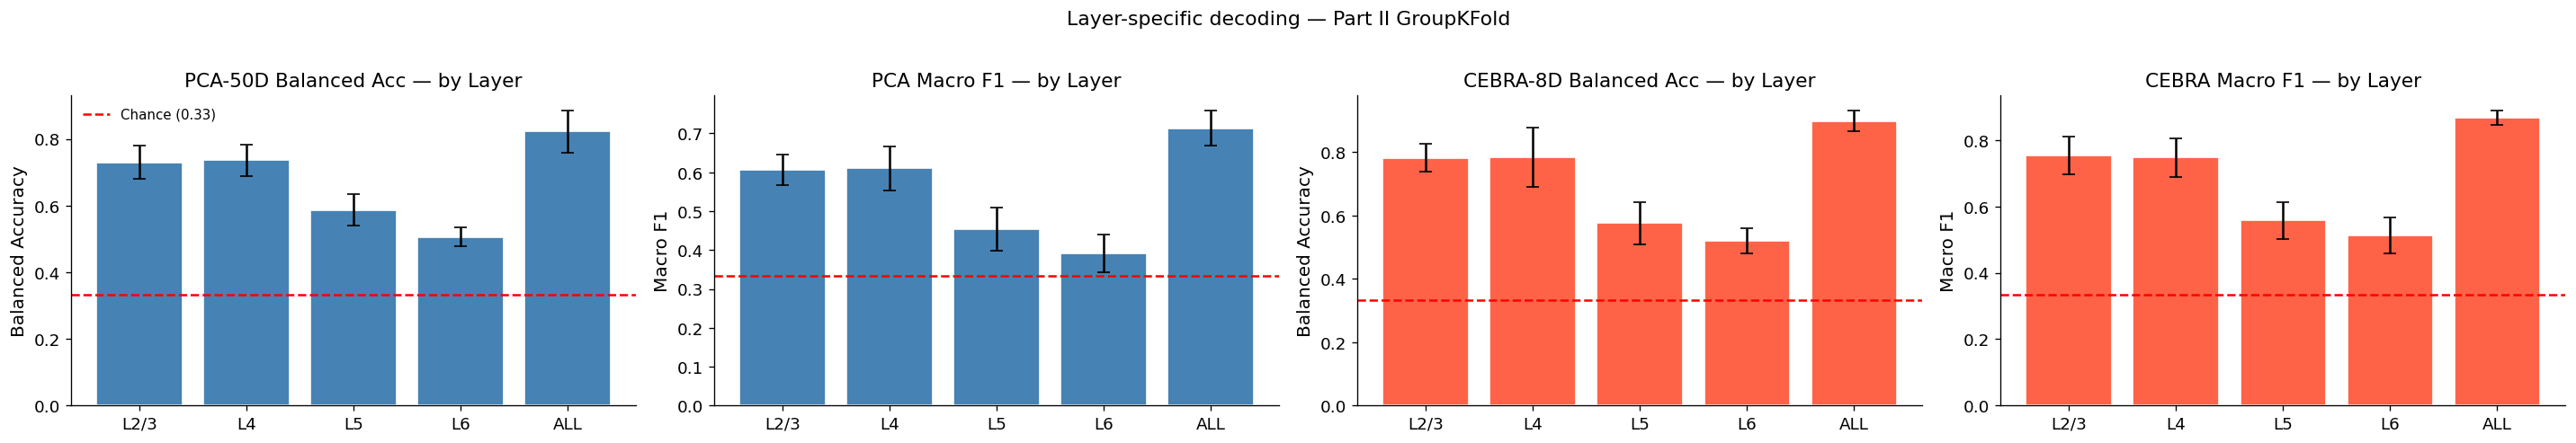

In [40]:
has_cebra_layer = 'cebra_bal_acc' in df_layer_p2.columns
n_plots = 4 if has_cebra_layer else 2
fig, axes = plt.subplots(1, n_plots, figsize=(6 * n_plots, 4))
x = np.arange(len(df_layer_p2))
layer_labels = df_layer_p2['layer'].tolist()

axes[0].bar(x, df_layer_p2['pca_bal_acc'],
            yerr=df_layer_p2['pca_bal_acc_std'],
            color='steelblue', edgecolor='white', capsize=4)
axes[0].axhline(chance_level_p2, color='red', ls='--',
                label=f'Chance ({chance_level_p2:.2f})')
axes[0].set_xticks(x); axes[0].set_xticklabels(layer_labels)
axes[0].set_ylabel('Balanced Accuracy')
axes[0].set_title(f'PCA-{N_PCS_FOR_CLF}D Balanced Acc — by Layer')
axes[0].legend(fontsize=9)

axes[1].bar(x, df_layer_p2['pca_f1'],
            yerr=df_layer_p2['pca_f1_std'],
            color='steelblue', edgecolor='white', capsize=4)
axes[1].axhline(chance_level_p2, color='red', ls='--')
axes[1].set_xticks(x); axes[1].set_xticklabels(layer_labels)
axes[1].set_ylabel('Macro F1')
axes[1].set_title('PCA Macro F1 — by Layer')

if has_cebra_layer:
    axes[2].bar(x, df_layer_p2['cebra_bal_acc'],
                yerr=df_layer_p2['cebra_bal_acc_std'],
                color='tomato', edgecolor='white', capsize=4)
    axes[2].axhline(chance_level_p2, color='red', ls='--')
    axes[2].set_xticks(x); axes[2].set_xticklabels(layer_labels)
    axes[2].set_ylabel('Balanced Accuracy')
    axes[2].set_title('CEBRA-8D Balanced Acc — by Layer')

    axes[3].bar(x, df_layer_p2['cebra_f1'],
                yerr=df_layer_p2['cebra_f1_std'],
                color='tomato', edgecolor='white', capsize=4)
    axes[3].axhline(chance_level_p2, color='red', ls='--')
    axes[3].set_xticks(x); axes[3].set_xticklabels(layer_labels)
    axes[3].set_ylabel('Macro F1')
    axes[3].set_title('CEBRA Macro F1 — by Layer')

plt.suptitle('Layer-specific decoding — Part II GroupKFold', y=1.02)
plt.tight_layout()
plt.show()
